# Cross-Domain Generalization in Deep Learning

## Overview

This notebook studies model generalization under domain shift.

The goal is to analyze how deep learning models behave when training and testing distributions are different.

## Problem Definition

Machine learning models often perform well when training and testing data follow the same distribution.

However, performance can degrade when models are deployed on unseen domains.

This experiment studies this challenge by evaluating model behavior under cross-domain scenarios.

## Experimental Pipeline

The experiment follows these steps:

1. Train a deep learning model on the source domain.
2. Evaluate the model on the original domain.
3. Test generalization on a different target domain.
4. Analyze learned feature representations.
5. Compare performance degradation under domain shift.

## Dataset and Domain Setup

The experiment uses multiple domains to evaluate cross-domain generalization.

The source domain is used for training, while target domains are used for evaluating robustness against distribution changes.

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm


SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


DATA_ROOT = "/content/data"
OUTPUT_DIR = "/content/q1_part_a_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


BATCH_SIZE = 128
NUM_WORKERS = 2
EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 5e-4


USE_SUBSET = True

SVHN_TRAIN_SUBSET = 5000
SVHN_TEST_SUBSET = 1000
MNIST_TEST_SUBSET = 1000

print("USE_SUBSET:", USE_SUBSET)

Device: cpu
USE_SUBSET: True


In [ ]:


svhn_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5))
])

mnist_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),  
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5))
])


svhn_train_full = datasets.SVHN(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=svhn_transform
)

svhn_test_full = datasets.SVHN(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=svhn_transform
)

mnist_test_full = datasets.MNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=mnist_transform
)

print("SVHN train size:", len(svhn_train_full))
print("SVHN test size:", len(svhn_test_full))
print("MNIST test size:", len(mnist_test_full))

x_svhn, y_svhn = svhn_train_full[0]
x_mnist, y_mnist = mnist_test_full[0]

print("SVHN sample shape:", x_svhn.shape, "label:", y_svhn)
print("MNIST sample shape after transform:", x_mnist.shape, "label:", y_mnist)

100%|██████████| 182M/182M [00:05<00:00, 34.0MB/s]
100%|██████████| 64.3M/64.3M [00:01<00:00, 39.2MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 464kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.83MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]

SVHN train size: 73257
SVHN test size: 26032
MNIST test size: 10000
SVHN sample shape: torch.Size([3, 32, 32]) label: 1
MNIST sample shape after transform: torch.Size([3, 32, 32]) label: 7


In [ ]:
def get_dataset_labels(dataset):
    """
    Extract labels from torchvision datasets.
    SVHN uses .labels
    MNIST uses .targets
    """
    if hasattr(dataset, "labels"):
        labels = dataset.labels
    elif hasattr(dataset, "targets"):
        labels = dataset.targets
    else:
        raise ValueError("Dataset has no labels or targets attribute.")

    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()
    else:
        labels = np.array(labels)

    return labels.astype(int)


def make_balanced_subset(dataset, n_samples, n_classes=10, seed=42):
    labels = get_dataset_labels(dataset)
    rng = np.random.default_rng(seed)

    indices = []
    per_class = n_samples // n_classes
    remainder = n_samples % n_classes

    for cls in range(n_classes):
        cls_indices = np.where(labels == cls)[0]
        n_take = per_class + (1 if cls < remainder else 0)
        n_take = min(n_take, len(cls_indices))

        selected = rng.choice(cls_indices, size=n_take, replace=False)
        indices.extend(selected.tolist())

    rng.shuffle(indices)
    return Subset(dataset, indices)


if USE_SUBSET:
    svhn_train = make_balanced_subset(svhn_train_full, SVHN_TRAIN_SUBSET, seed=SEED)
    svhn_test = make_balanced_subset(svhn_test_full, SVHN_TEST_SUBSET, seed=SEED)
    mnist_test = make_balanced_subset(mnist_test_full, MNIST_TEST_SUBSET, seed=SEED)
else:
    svhn_train = svhn_train_full
    svhn_test = svhn_test_full
    mnist_test = mnist_test_full

print("Used SVHN train size:", len(svhn_train))
print("Used SVHN test size:", len(svhn_test))
print("Used MNIST test size:", len(mnist_test))

Used SVHN train size: 5000
Used SVHN test size: 1000
Used MNIST test size: 1000


In [ ]:
pin_memory = True if torch.cuda.is_available() else False

svhn_train_loader = DataLoader(
    svhn_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

svhn_test_loader = DataLoader(
    svhn_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

mnist_test_loader = DataLoader(
    mnist_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("Train batches:", len(svhn_train_loader))
print("SVHN test batches:", len(svhn_test_loader))
print("MNIST test batches:", len(mnist_test_loader))

Train batches: 40
SVHN test batches: 8
MNIST test batches: 8


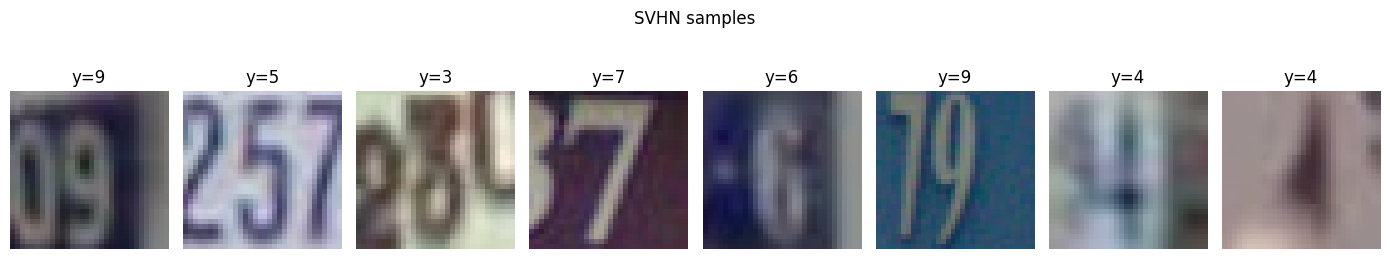

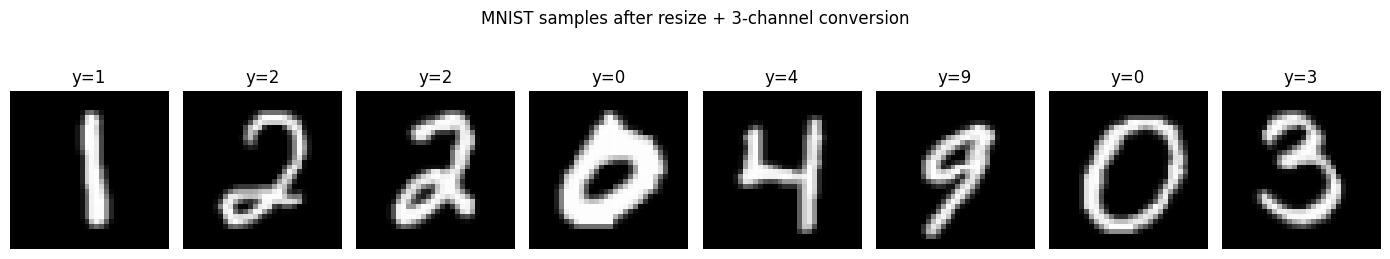

In [ ]:
def unnormalize(img):
    """
    img: tensor [C, H, W]
    """
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)


def show_batch(loader, title, n=8):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]

    plt.figure(figsize=(14, 3))
    for i in range(n):
        img = unnormalize(images[i]).permute(1, 2, 0).numpy()
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f"y={labels[i].item()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_batch(svhn_train_loader, "SVHN samples")
show_batch(mnist_test_loader, "MNIST samples after resize + 3-channel conversion")

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمونه‌های ورودی</h3>

<p>
در این بخش چند نمونه از داده‌های SVHN و MNIST نمایش داده شده است. تصاویر SVHN رنگی، دارای پس‌زمینه واقعی و نویز تصویری هستند، در حالی که تصاویر MNIST ساده‌تر، خاکستری و با پس‌زمینه یکنواخت‌اند. بنابراین از همان ابتدا می‌توان مشاهده کرد که بین دو مجموعه‌داده یک تفاوت ظاهری و آماری جدی وجود دارد.
</p>

<p>
برای اینکه هر دو مجموعه‌داده قابل ورود به مدل باشند، تصاویر MNIST به اندازه ۳۲×۳۲ تغییر اندازه داده شده و کانال خاکستری آن‌ها به سه کانال تبدیل شده است. با این حال، یکسان‌سازی اندازه و تعداد کانال‌ها به معنی حذف کامل تفاوت دامنه نیست؛ زیرا رنگ، بافت، پس‌زمینه و سبک تصویربرداری همچنان متفاوت باقی می‌مانند.
</p>

</div>

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, use_bn=True):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(planes) if use_bn else nn.Identity()

        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(planes) if use_bn else nn.Identity()

        self.relu = nn.ReLU(inplace=True)


        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes * self.expansion) if use_bn else nn.Identity()
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


class ResNet18Small(nn.Module):
    """
    Manual ResNet18 adapted for 32x32 images.
    Layer configuration: [2, 2, 2, 2]
    """

    def __init__(self, num_classes=10, use_bn=True):
        super().__init__()

        self.in_planes = 64
        self.use_bn = use_bn

        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64) if use_bn else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)

        layers = []
        for s in strides:
            layers.append(
                BasicBlock(
                    in_planes=self.in_planes,
                    planes=planes,
                    stride=s,
                    use_bn=self.use_bn
                )
            )
            self.in_planes = planes * BasicBlock.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out


# Test model shape
model_test = ResNet18Small(num_classes=10, use_bn=True)
dummy = torch.randn(4, 3, 32, 32)
out = model_test(dummy)

print("Output shape:", out.shape)

Output shape: torch.Size([4, 10])


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        progress_bar.set_postfix({
            "loss": running_loss / total,
            "acc": correct / total
        })

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    eval_loss = running_loss / total
    eval_acc = correct / total

    return eval_loss, eval_acc

In [ ]:
model = ResNet18Small(num_classes=10, use_bn=True).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

history = []

print("Start training...")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=svhn_train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    svhn_test_loss, svhn_test_acc = evaluate(
        model=model,
        loader=svhn_test_loader,
        criterion=criterion,
        device=device
    )

    mnist_test_loss, mnist_test_acc = evaluate(
        model=model,
        loader=mnist_test_loader,
        criterion=criterion,
        device=device
    )

    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "svhn_test_loss": svhn_test_loss,
        "svhn_test_acc": svhn_test_acc,
        "mnist_test_loss": mnist_test_loss,
        "mnist_test_acc": mnist_test_acc,
        "lr": optimizer.param_groups[0]["lr"],
        "epoch_time_sec": time.time() - epoch_start
    }

    history.append(row)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"SVHN Test Acc: {svhn_test_acc:.4f} | "
        f"MNIST Test Acc: {mnist_test_acc:.4f} | "
        f"Time: {row['epoch_time_sec']:.1f}s"
    )

total_time = time.time() - start_time
print(f"Total training time: {total_time / 60:.2f} minutes")

Start training...


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [01/15] | Train Loss: 2.4102 | Train Acc: 0.1084 | SVHN Test Acc: 0.1260 | MNIST Test Acc: 0.0920 | Time: 118.4s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [02/15] | Train Loss: 2.2929 | Train Acc: 0.1414 | SVHN Test Acc: 0.1760 | MNIST Test Acc: 0.1000 | Time: 117.3s


...

Epoch [13/15] | Train Loss: 0.0571 | Train Acc: 0.9914 | SVHN Test Acc: 0.8580 | MNIST Test Acc: 0.6030 | Time: 118.3s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [14/15] | Train Loss: 0.0418 | Train Acc: 0.9962 | SVHN Test Acc: 0.8560 | MNIST Test Acc: 0.5900 | Time: 119.1s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [15/15] | Train Loss: 0.0378 | Train Acc: 0.9970 | SVHN Test Acc: 0.8580 | MNIST Test Acc: 0.5920 | Time: 117.0s
Total training time: 29.87 minutes


In [ ]:
history_df = pd.DataFrame(history)

history_path = os.path.join(OUTPUT_DIR, "q1a_training_history.csv")
history_df.to_csv(history_path, index=False)

print("Saved history to:", history_path)
history_df

Saved history to: /content/q1_part_a_outputs/q1a_training_history.csv


,epoch,train_loss,train_acc,svhn_test_loss,svhn_test_acc,mnist_test_loss,mnist_test_acc,lr,epoch_time_sec
0,1,2.410196,0.1084,2.325137,0.126,2.457773,0.092,0.000989,118.443442
1,2,2.292855,0.1414,2.369107,0.176,3.832498,0.100,0.000957,117.313727
2,3,2.181357,0.2094,2.196684,0.270,2.470935,0.144,0.000905,117.202692
3,4,1.823407,0.3554,2.032302,0.364,3.559235,0.124,0.000835,115.889034
4,5,1.406002,0.5342,1.106063,0.628,1.764456,0.455,0.000750,117.799438
5,6,0.837274,0.7194,0.927622,0.674,1.857331,0.463,0.000655,117.317656
6,7,0.542831,0.8232,0.737091,0.747,1.488888,0.522,0.000552,117.690557
7,8,0.445606,0.8544,0.582073,0.793,2.647536,0.462,0.000448,116.998619
8,9,0.283483,0.9124,0.491842,0.835,1.254267,0.582,0.000345,120.887695
9,10,0.178604,0.9494,0.447875,0.863,1.287681,0.607,0.000250,131.714542


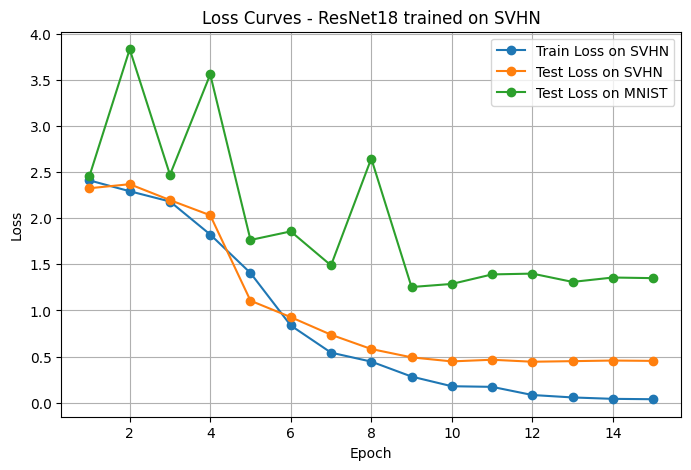

Saved: /content/q1_part_a_outputs/q1a_loss_curves.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss on SVHN")
plt.plot(history_df["epoch"], history_df["svhn_test_loss"], marker="o", label="Test Loss on SVHN")
plt.plot(history_df["epoch"], history_df["mnist_test_loss"], marker="o", label="Test Loss on MNIST")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves - ResNet18 trained on SVHN")
plt.legend()
plt.grid(True)

loss_fig_path = os.path.join(OUTPUT_DIR, "q1a_loss_curves.png")
plt.savefig(loss_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", loss_fig_path)

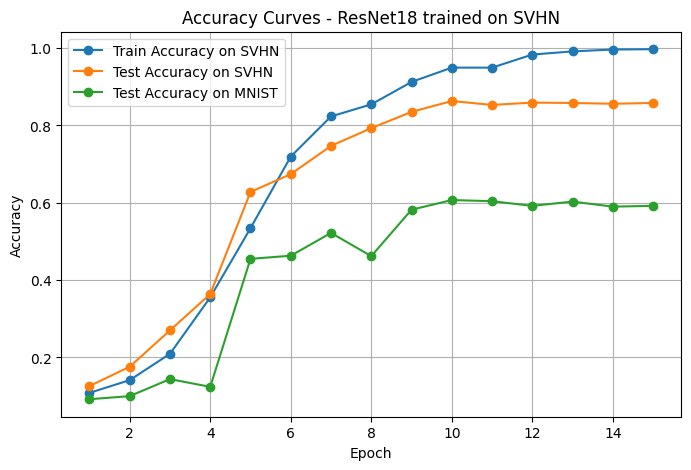

Saved: /content/q1_part_a_outputs/q1a_accuracy_curves.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train Accuracy on SVHN")
plt.plot(history_df["epoch"], history_df["svhn_test_acc"], marker="o", label="Test Accuracy on SVHN")
plt.plot(history_df["epoch"], history_df["mnist_test_acc"], marker="o", label="Test Accuracy on MNIST")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves - ResNet18 trained on SVHN")
plt.legend()
plt.grid(True)

acc_fig_path = os.path.join(OUTPUT_DIR, "q1a_accuracy_curves.png")
plt.savefig(acc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", acc_fig_path)

In [ ]:
final_row = history_df.iloc[-1]

results = pd.DataFrame([
    {
        "Model": "Manual ResNet18",
        "Train Domain": "SVHN",
        "Test Domain": "SVHN",
        "Final Test Loss": final_row["svhn_test_loss"],
        "Final Test Accuracy": final_row["svhn_test_acc"]
    },
    {
        "Model": "Manual ResNet18",
        "Train Domain": "SVHN",
        "Test Domain": "MNIST",
        "Final Test Loss": final_row["mnist_test_loss"],
        "Final Test Accuracy": final_row["mnist_test_acc"]
    }
])

results_path = os.path.join(OUTPUT_DIR, "q1a_final_results.csv")
results.to_csv(results_path, index=False)

results

,Model,Train Domain,Test Domain,Final Test Loss,Final Test Accuracy
0,Manual ResNet18,SVHN,SVHN,0.453495,0.858
1,Manual ResNet18,SVHN,MNIST,1.350559,0.592


In [ ]:
model_path = os.path.join(OUTPUT_DIR, "q1a_resnet18_svhn_baseline.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "config": {
        "model": "Manual ResNet18Small",
        "train_dataset": "SVHN",
        "test_datasets": ["SVHN", "MNIST"],
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "use_subset": USE_SUBSET,
        "svhn_train_subset": SVHN_TRAIN_SUBSET if USE_SUBSET else None,
        "svhn_test_subset": SVHN_TEST_SUBSET if USE_SUBSET else None,
        "mnist_test_subset": MNIST_TEST_SUBSET if USE_SUBSET else None
    },
    "history": history
}, model_path)

print("Model saved to:", model_path)

Model saved to: /content/q1_part_a_outputs/q1a_resnet18_svhn_baseline.pth


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل بخش الف: مدل پایه و تعمیم‌پذیری</h3>

<p>
نتایج بخش الف نشان می‌دهد که مدل ResNet18 آموزش‌دیده روی SVHN توانسته روی دامنه منبع عملکرد قابل قبولی داشته باشد. دقت نهایی روی آزمون SVHN برابر با 0.858 است، اما همین مدل روی MNIST فقط به دقت 0.592 رسیده است. این اختلاف نشان می‌دهد که مدل بخشی از مفهوم کلی ارقام را یاد گرفته، اما همچنان به ویژگی‌های خاص دامنه SVHN وابسته مانده است.
</p>

<p>
در نمودار Loss مشاهده می‌شود که خطای آموزش به‌مرور کاهش پیدا می‌کند، اما خطای MNIST نسبت به SVHN بالاتر و ناپایدارتر باقی می‌ماند. همچنین در نمودار Accuracy، دقت آموزش تقریباً به 0.997 رسیده، در حالی که دقت آزمون SVHN پایین‌تر و دقت MNIST بسیار پایین‌تر است. بنابراین بخشی از مشکل مربوط به overfitting روی دامنه منبع است، اما مسئله اصلی‌تر وجود domain shift یا به طور دقیق‌تر covariate shift بین SVHN و MNIST است.
</p>

</div>

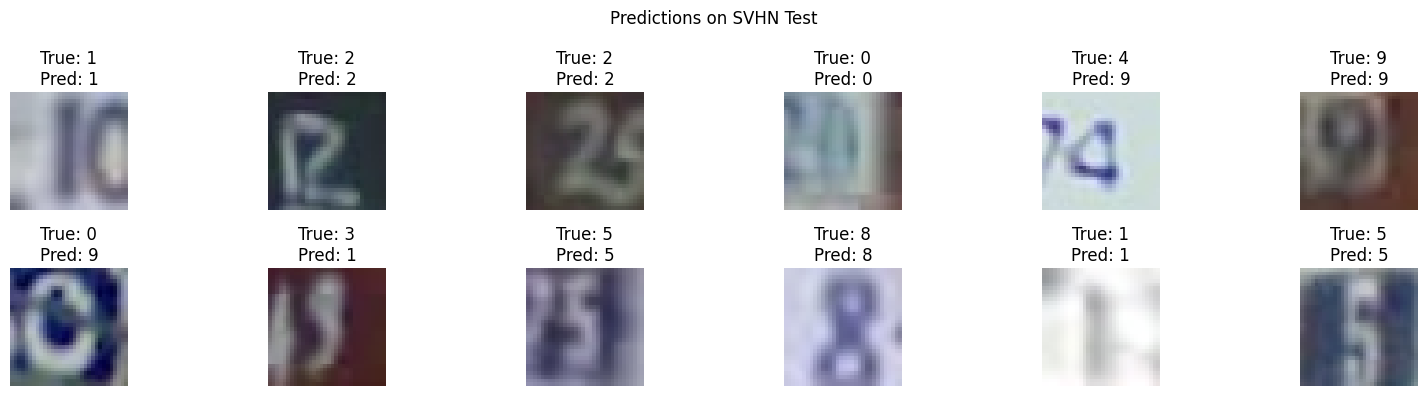

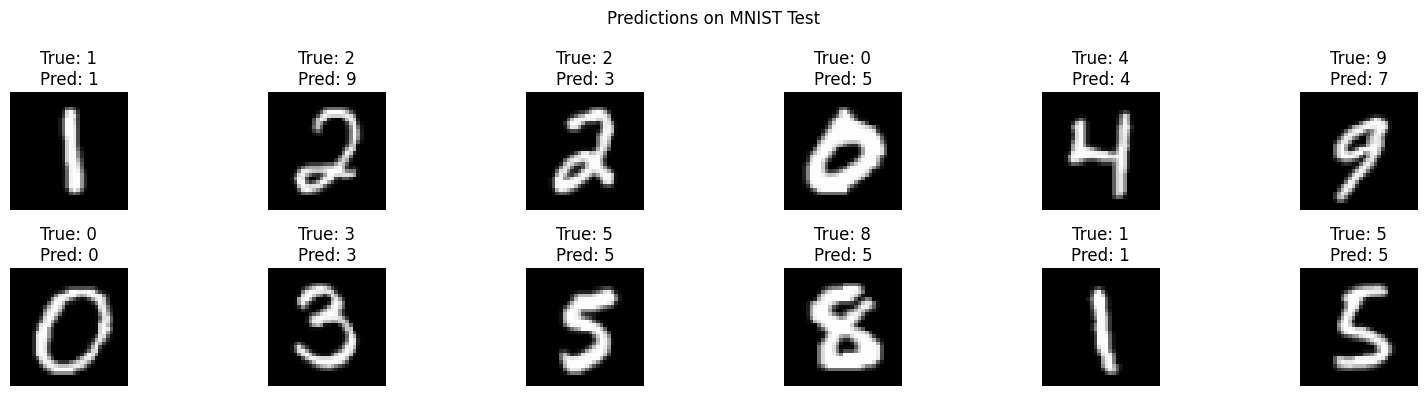

In [ ]:
@torch.no_grad()
def show_predictions(model, loader, title, n=12):
    model.eval()

    images, labels = next(iter(loader))
    images = images.to(device)
    labels = labels.to(device)

    logits = model(images)
    preds = logits.argmax(dim=1)

    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()

    plt.figure(figsize=(16, 4))

    for i in range(n):
        img = unnormalize(images[i]).permute(1, 2, 0).numpy()

        plt.subplot(2, n // 2, i + 1)
        plt.imshow(img)
        plt.title(f"True: {labels[i].item()}\nPred: {preds[i].item()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_predictions(model, svhn_test_loader, "Predictions on SVHN Test")
show_predictions(model, mnist_test_loader, "Predictions on MNIST Test")

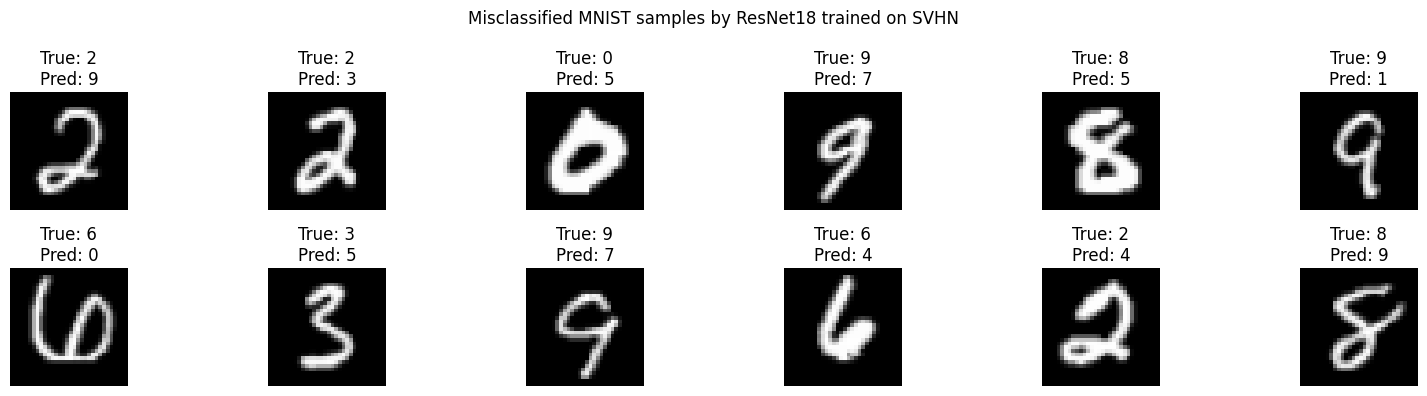

In [ ]:
@torch.no_grad()
def show_misclassified_samples(model, loader, title, max_samples=12):
    model.eval()

    wrong_images = []
    wrong_labels = []
    wrong_preds = []

    for images, labels in loader:
        images_gpu = images.to(device)
        labels_gpu = labels.to(device)

        logits = model(images_gpu)
        preds = logits.argmax(dim=1)

        wrong_mask = preds != labels_gpu

        if wrong_mask.any():
            wrong_images.append(images[wrong_mask.cpu()])
            wrong_labels.append(labels[wrong_mask.cpu()])
            wrong_preds.append(preds[wrong_mask].cpu())

        total_wrong = sum(x.size(0) for x in wrong_images)
        if total_wrong >= max_samples:
            break

    if len(wrong_images) == 0:
        print("No misclassified samples found.")
        return

    wrong_images = torch.cat(wrong_images, dim=0)[:max_samples]
    wrong_labels = torch.cat(wrong_labels, dim=0)[:max_samples]
    wrong_preds = torch.cat(wrong_preds, dim=0)[:max_samples]

    n = wrong_images.size(0)

    plt.figure(figsize=(16, 4))

    for i in range(n):
        img = unnormalize(wrong_images[i]).permute(1, 2, 0).numpy()

        plt.subplot(2, max_samples // 2, i + 1)
        plt.imshow(img)
        plt.title(f"True: {wrong_labels[i].item()}\nPred: {wrong_preds[i].item()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_misclassified_samples(
    model,
    mnist_test_loader,
    title="Misclassified MNIST samples by ResNet18 trained on SVHN",
    max_samples=12
)

In [ ]:


import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

NUM_WORKERS = 0

PART_B_DIR = os.path.join(OUTPUT_DIR, "part_b")
os.makedirs(PART_B_DIR, exist_ok=True)

EPOCHS_B = 15
LR_B = 1e-3
WEIGHT_DECAY_B = 5e-4

print("Part B output directory:", PART_B_DIR)
print("Device:", device)

Part B output directory: /content/q1_part_a_outputs/part_b
Device: cpu


In [ ]:


baseline_history_df = history_df.copy()
baseline_history_df["experiment"] = "Baseline_BN_CE"

baseline_final = baseline_history_df.iloc[-1]

baseline_summary = {
    "experiment": "Baseline_BN_CE",
    "use_bn": True,
    "label_smoothing": 0.0,
    "final_train_loss": baseline_final["train_loss"],
    "final_train_acc": baseline_final["train_acc"],
    "final_svhn_test_loss": baseline_final["svhn_test_loss"],
    "final_svhn_test_acc": baseline_final["svhn_test_acc"],
    "final_mnist_test_loss": baseline_final["mnist_test_loss"],
    "final_mnist_test_acc": baseline_final["mnist_test_acc"],
}

baseline_summary

{'experiment': 'Baseline_BN_CE',
 'use_bn': True,
 'label_smoothing': 0.0,
 'final_train_loss': np.float64(0.037808377480506895),
 'final_train_acc': np.float64(0.997),
 'final_svhn_test_loss': np.float64(0.453495322227478),
 'final_svhn_test_acc': np.float64(0.858),
 'final_mnist_test_loss': np.float64(1.350558656692505),
 'final_mnist_test_acc': np.float64(0.592)}

In [ ]:
history_df = pd.DataFrame(history)

In [ ]:


def run_part_b_experiment(
    experiment_name,
    use_bn=True,
    label_smoothing=0.0,
    epochs=15,
    lr=1e-3,
    weight_decay=5e-4
):
    """
    Train ResNet18Small on SVHN and evaluate on SVHN test and MNIST test.

    experiment_name:
        Name of the experiment for logging and saving.

    use_bn:
        If False, all BatchNorm layers in the manual ResNet18 are replaced by Identity.

    label_smoothing:
        If > 0, CrossEntropyLoss uses label smoothing.
    """

    print("=" * 80)
    print(f"Starting experiment: {experiment_name}")
    print(f"use_bn = {use_bn}")
    print(f"label_smoothing = {label_smoothing}")
    print("=" * 80)

    set_seed(SEED)

    model_exp = ResNet18Small(num_classes=10, use_bn=use_bn).to(device)

    criterion_exp = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    optimizer_exp = optim.AdamW(
        model_exp.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler_exp = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_exp,
        T_max=epochs
    )

    history_exp = []

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(
            model=model_exp,
            loader=svhn_train_loader,
            criterion=criterion_exp,
            optimizer=optimizer_exp,
            device=device
        )

        svhn_test_loss, svhn_test_acc = evaluate(
            model=model_exp,
            loader=svhn_test_loader,
            criterion=criterion_exp,
            device=device
        )

        mnist_test_loss, mnist_test_acc = evaluate(
            model=model_exp,
            loader=mnist_test_loader,
            criterion=criterion_exp,
            device=device
        )

        scheduler_exp.step()

        row = {
            "experiment": experiment_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "svhn_test_loss": svhn_test_loss,
            "svhn_test_acc": svhn_test_acc,
            "mnist_test_loss": mnist_test_loss,
            "mnist_test_acc": mnist_test_acc,
            "lr": optimizer_exp.param_groups[0]["lr"],
            "epoch_time_sec": time.time() - epoch_start,
            "use_bn": use_bn,
            "label_smoothing": label_smoothing
        }

        history_exp.append(row)

        print(
            f"Epoch [{epoch:02d}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"SVHN Test Acc: {svhn_test_acc:.4f} | "
            f"MNIST Test Acc: {mnist_test_acc:.4f} | "
            f"Time: {row['epoch_time_sec']:.1f}s"
        )

    total_time = time.time() - start_time
    print(f"Total time for {experiment_name}: {total_time / 60:.2f} minutes")

    history_exp_df = pd.DataFrame(history_exp)

    history_path = os.path.join(PART_B_DIR, f"{experiment_name}_history.csv")
    history_exp_df.to_csv(history_path, index=False)

    model_path = os.path.join(PART_B_DIR, f"{experiment_name}_model.pth")
    torch.save({
        "experiment_name": experiment_name,
        "model_state_dict": model_exp.state_dict(),
        "history": history_exp,
        "config": {
            "use_bn": use_bn,
            "label_smoothing": label_smoothing,
            "epochs": epochs,
            "lr": lr,
            "weight_decay": weight_decay
        }
    }, model_path)

    print("Saved history:", history_path)
    print("Saved model:", model_path)

    return model_exp, history_exp_df

In [ ]:


model_no_bn, no_bn_history_df = run_part_b_experiment(
    experiment_name="No_BN_CE",
    use_bn=False,
    label_smoothing=0.0,
    epochs=EPOCHS_B,
    lr=LR_B,
    weight_decay=WEIGHT_DECAY_B
)

no_bn_history_df

Starting experiment: No_BN_CE
use_bn = False
label_smoothing = 0.0


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac4b18de7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7ac4b18de7a0>Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/d

Epoch [01/15] | Train Loss: 2.3193 | Train Acc: 0.0994 | SVHN Test Acc: 0.1000 | MNIST Test Acc: 0.1000 | Time: 107.1s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac4b18de7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x7ac4b18de7a0>self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
        if w.is_alive():self._shutdown_workers()

   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
       if w.is_alive(): 
   ^  ^ ^ ^ ^ ^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^  
   File "/usr/lib/pyt

Epoch [14/15] | Train Loss: 1.3431 | Train Acc: 0.5386 | SVHN Test Acc: 0.4980 | MNIST Test Acc: 0.3120 | Time: 110.6s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [15/15] | Train Loss: 1.2956 | Train Acc: 0.5572 | SVHN Test Acc: 0.5040 | MNIST Test Acc: 0.3360 | Time: 100.9s
Total time for No_BN_CE: 26.09 minutes
Saved history: /content/q1_part_a_outputs/part_b/No_BN_CE_history.csv
Saved model: /content/q1_part_a_outputs/part_b/No_BN_CE_model.pth


,experiment,epoch,train_loss,train_acc,svhn_test_loss,svhn_test_acc,mnist_test_loss,mnist_test_acc,lr,epoch_time_sec,use_bn,label_smoothing
0,No_BN_CE,1,2.319306,0.0994,2.302858,0.100,2.302836,0.100,0.000989,107.104097,False,0.0
1,No_BN_CE,2,2.302867,0.1000,2.304092,0.100,2.304815,0.094,0.000957,105.794276,False,0.0
2,No_BN_CE,3,2.303008,0.0962,2.302776,0.103,2.302718,0.100,0.000905,102.493215,False,0.0
3,No_BN_CE,4,2.302704,0.1030,2.300768,0.108,2.303150,0.096,0.000835,101.414147,False,0.0
4,No_BN_CE,5,2.302302,0.1098,2.299467,0.098,2.309381,0.100,0.000750,104.994771,False,0.0
5,No_BN_CE,6,2.288741,0.1132,2.273367,0.133,2.446897,0.100,0.000655,101.804195,False,0.0
6,No_BN_CE,7,2.210828,0.1584,2.163741,0.180,2.370935,0.109,0.000552,103.991502,False,0.0
7,No_BN_CE,8,2.132810,0.1976,2.033855,0.226,2.303855,0.183,0.000448,102.606872,False,0.0
8,No_BN_CE,9,2.052223,0.2434,2.005480,0.265,2.271638,0.202,0.000345,105.194915,False,0.0
9,No_BN_CE,10,1.937803,0.2984,2.066713,0.252,2.946608,0.190,0.000250,102.281834,False,0.0


In [ ]:


model_label_smoothing, label_smoothing_history_df = run_part_b_experiment(
    experiment_name="BN_LabelSmoothing_01",
    use_bn=True,
    label_smoothing=0.1,
    epochs=EPOCHS_B,
    lr=LR_B,
    weight_decay=WEIGHT_DECAY_B
)

label_smoothing_history_df

Starting experiment: BN_LabelSmoothing_01
use_bn = True
label_smoothing = 0.1


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [01/15] | Train Loss: 2.4215 | Train Acc: 0.1132 | SVHN Test Acc: 0.1250 | MNIST Test Acc: 0.1030 | Time: 110.1s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [02/15] | Train Loss: 2.2961 | Train Acc: 0.1400 | SVHN Test Acc: 0.1410 | MNIST Test Acc: 0.0630 | Time: 110.8s


...

Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [14/15] | Train Loss: 0.5386 | Train Acc: 0.9992 | SVHN Test Acc: 0.8750 | MNIST Test Acc: 0.6480 | Time: 108.6s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [15/15] | Train Loss: 0.5354 | Train Acc: 0.9992 | SVHN Test Acc: 0.8750 | MNIST Test Acc: 0.6450 | Time: 110.2s
Total time for BN_LabelSmoothing_01: 27.63 minutes
Saved history: /content/q1_part_a_outputs/part_b/BN_LabelSmoothing_01_history.csv
Saved model: /content/q1_part_a_outputs/part_b/BN_LabelSmoothing_01_model.pth


,experiment,epoch,train_loss,train_acc,svhn_test_loss,svhn_test_acc,mnist_test_loss,mnist_test_acc,lr,epoch_time_sec,use_bn,label_smoothing
0,BN_LabelSmoothing_01,1,2.421470,0.1132,2.449543,0.125,2.298417,0.103,0.000989,110.135957,True,0.1
1,BN_LabelSmoothing_01,2,2.296053,0.1400,2.294905,0.141,2.285436,0.063,0.000957,110.801176,True,0.1
2,BN_LabelSmoothing_01,3,2.240204,0.1878,2.144931,0.246,2.305999,0.201,0.000905,110.005737,True,0.1
3,BN_LabelSmoothing_01,4,1.859746,0.3874,1.935579,0.434,2.801128,0.252,0.000835,109.278898,True,0.1
4,BN_LabelSmoothing_01,5,1.257218,0.6794,1.159495,0.740,1.332542,0.639,0.000750,108.506707,True,0.1
5,BN_LabelSmoothing_01,6,0.958473,0.8208,1.077874,0.765,1.611318,0.516,0.000655,112.312934,True,0.1
6,BN_LabelSmoothing_01,7,0.824543,0.8846,0.921099,0.832,1.347531,0.648,0.000552,115.282391,True,0.1
7,BN_LabelSmoothing_01,8,0.733860,0.9274,0.932689,0.832,1.383446,0.603,0.000448,118.721372,True,0.1
8,BN_LabelSmoothing_01,9,0.690226,0.9454,0.869636,0.857,1.248473,0.673,0.000345,108.200115,True,0.1
9,BN_LabelSmoothing_01,10,0.625533,0.9728,0.848067,0.868,1.274290,0.650,0.000250,109.992451,True,0.1


In [ ]:


@torch.no_grad()
def evaluate_confidence(model, loader, device):
    model.eval()

    total = 0
    correct = 0

    all_confidences = []
    correct_confidences = []
    wrong_confidences = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)

        confidences, preds = probs.max(dim=1)

        is_correct = preds == labels

        total += labels.size(0)
        correct += is_correct.sum().item()

        all_confidences.extend(confidences.detach().cpu().numpy().tolist())

        if is_correct.any():
            correct_confidences.extend(confidences[is_correct].detach().cpu().numpy().tolist())

        if (~is_correct).any():
            wrong_confidences.extend(confidences[~is_correct].detach().cpu().numpy().tolist())

    accuracy = correct / total
    avg_conf = float(np.mean(all_confidences))

    avg_conf_correct = float(np.mean(correct_confidences)) if len(correct_confidences) > 0 else None
    avg_conf_wrong = float(np.mean(wrong_confidences)) if len(wrong_confidences) > 0 else None

    return {
        "accuracy": accuracy,
        "avg_confidence": avg_conf,
        "avg_confidence_correct": avg_conf_correct,
        "avg_confidence_wrong": avg_conf_wrong
    }

In [ ]:

confidence_rows = []

models_for_confidence = [
    ("Baseline_BN_CE", model),
    ("No_BN_CE", model_no_bn),
    ("BN_LabelSmoothing_01", model_label_smoothing)
]

for exp_name, exp_model in models_for_confidence:
    svhn_conf = evaluate_confidence(exp_model, svhn_test_loader, device)
    mnist_conf = evaluate_confidence(exp_model, mnist_test_loader, device)

    confidence_rows.append({
        "experiment": exp_name,
        "test_domain": "SVHN",
        **svhn_conf
    })

    confidence_rows.append({
        "experiment": exp_name,
        "test_domain": "MNIST",
        **mnist_conf
    })

confidence_df = pd.DataFrame(confidence_rows)

confidence_path = os.path.join(PART_B_DIR, "part_b_confidence_comparison.csv")
confidence_df.to_csv(confidence_path, index=False)

confidence_df

,experiment,test_domain,accuracy,avg_confidence,avg_confidence_correct,avg_confidence_wrong
0,Baseline_BN_CE,SVHN,0.858,0.899706,0.936835,0.675365
1,Baseline_BN_CE,MNIST,0.592,0.770582,0.850023,0.655314
2,No_BN_CE,SVHN,0.504,0.492935,0.597924,0.386254
3,No_BN_CE,MNIST,0.336,0.661965,0.737464,0.623761
4,BN_LabelSmoothing_01,SVHN,0.875,0.784463,0.823189,0.513380
5,BN_LabelSmoothing_01,MNIST,0.645,0.608544,0.678520,0.481406


In [ ]:


def get_final_summary(history_df, experiment_name, use_bn, label_smoothing):
    final = history_df.iloc[-1]

    return {
        "experiment": experiment_name,
        "use_bn": use_bn,
        "label_smoothing": label_smoothing,
        "final_train_loss": final["train_loss"],
        "final_train_acc": final["train_acc"],
        "final_svhn_test_loss": final["svhn_test_loss"],
        "final_svhn_test_acc": final["svhn_test_acc"],
        "final_mnist_test_loss": final["mnist_test_loss"],
        "final_mnist_test_acc": final["mnist_test_acc"],
    }


summary_rows = []

summary_rows.append(
    get_final_summary(
        baseline_history_df,
        "Baseline_BN_CE",
        use_bn=True,
        label_smoothing=0.0
    )
)

summary_rows.append(
    get_final_summary(
        no_bn_history_df,
        "No_BN_CE",
        use_bn=False,
        label_smoothing=0.0
    )
)

summary_rows.append(
    get_final_summary(
        label_smoothing_history_df,
        "BN_LabelSmoothing_01",
        use_bn=True,
        label_smoothing=0.1
    )
)

part_b_summary_df = pd.DataFrame(summary_rows)

summary_path = os.path.join(PART_B_DIR, "part_b_final_summary.csv")
part_b_summary_df.to_csv(summary_path, index=False)

part_b_summary_df

,experiment,use_bn,label_smoothing,final_train_loss,final_train_acc,final_svhn_test_loss,final_svhn_test_acc,final_mnist_test_loss,final_mnist_test_acc
0,Baseline_BN_CE,True,0.0,0.037808,0.9970,0.453495,0.858,1.350559,0.592
1,No_BN_CE,False,0.0,1.295590,0.5572,1.445754,0.504,3.729201,0.336
2,BN_LabelSmoothing_01,True,0.1,0.535392,0.9992,0.831750,0.875,1.302376,0.645


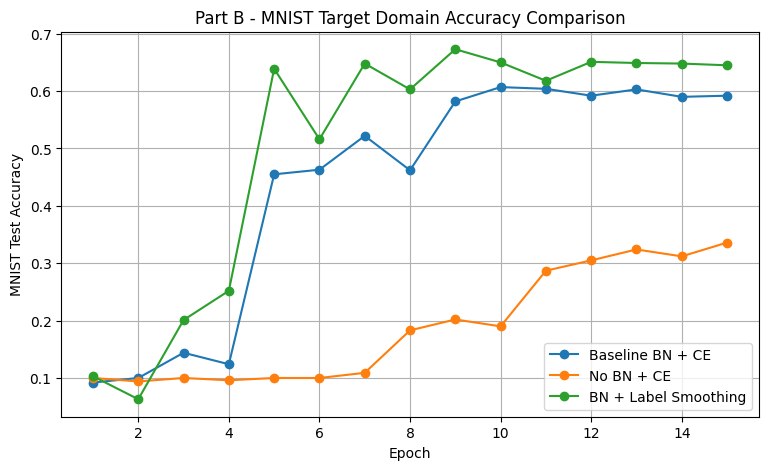

Saved: /content/q1_part_a_outputs/part_b/part_b_mnist_accuracy_comparison.png


In [ ]:


plt.figure(figsize=(9, 5))

plt.plot(
    baseline_history_df["epoch"],
    baseline_history_df["mnist_test_acc"],
    marker="o",
    label="Baseline BN + CE"
)

plt.plot(
    no_bn_history_df["epoch"],
    no_bn_history_df["mnist_test_acc"],
    marker="o",
    label="No BN + CE"
)

plt.plot(
    label_smoothing_history_df["epoch"],
    label_smoothing_history_df["mnist_test_acc"],
    marker="o",
    label="BN + Label Smoothing"
)

plt.xlabel("Epoch")
plt.ylabel("MNIST Test Accuracy")
plt.title("Part B - MNIST Target Domain Accuracy Comparison")
plt.legend()
plt.grid(True)

mnist_acc_fig_path = os.path.join(PART_B_DIR, "part_b_mnist_accuracy_comparison.png")
plt.savefig(mnist_acc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", mnist_acc_fig_path)

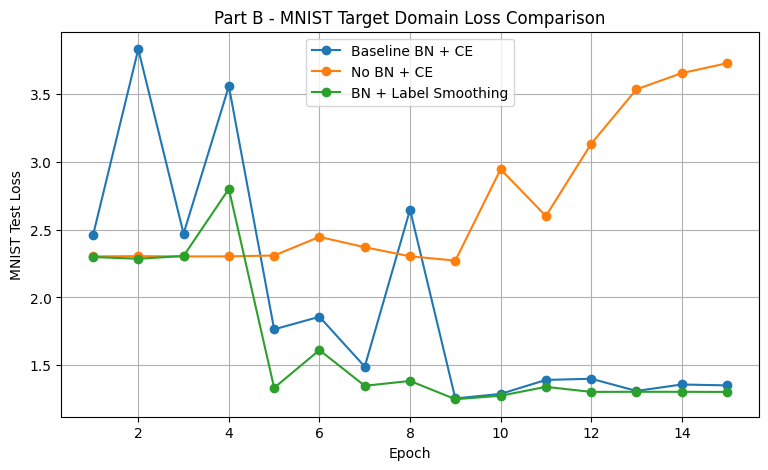

Saved: /content/q1_part_a_outputs/part_b/part_b_mnist_loss_comparison.png


In [ ]:


plt.figure(figsize=(9, 5))

plt.plot(
    baseline_history_df["epoch"],
    baseline_history_df["mnist_test_loss"],
    marker="o",
    label="Baseline BN + CE"
)

plt.plot(
    no_bn_history_df["epoch"],
    no_bn_history_df["mnist_test_loss"],
    marker="o",
    label="No BN + CE"
)

plt.plot(
    label_smoothing_history_df["epoch"],
    label_smoothing_history_df["mnist_test_loss"],
    marker="o",
    label="BN + Label Smoothing"
)

plt.xlabel("Epoch")
plt.ylabel("MNIST Test Loss")
plt.title("Part B - MNIST Target Domain Loss Comparison")
plt.legend()
plt.grid(True)

mnist_loss_fig_path = os.path.join(PART_B_DIR, "part_b_mnist_loss_comparison.png")
plt.savefig(mnist_loss_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", mnist_loss_fig_path)

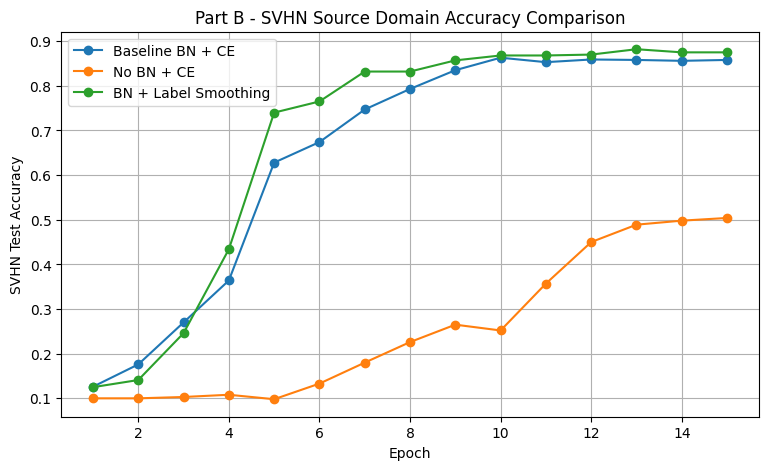

Saved: /content/q1_part_a_outputs/part_b/part_b_svhn_accuracy_comparison.png


In [ ]:


plt.figure(figsize=(9, 5))

plt.plot(
    baseline_history_df["epoch"],
    baseline_history_df["svhn_test_acc"],
    marker="o",
    label="Baseline BN + CE"
)

plt.plot(
    no_bn_history_df["epoch"],
    no_bn_history_df["svhn_test_acc"],
    marker="o",
    label="No BN + CE"
)

plt.plot(
    label_smoothing_history_df["epoch"],
    label_smoothing_history_df["svhn_test_acc"],
    marker="o",
    label="BN + Label Smoothing"
)

plt.xlabel("Epoch")
plt.ylabel("SVHN Test Accuracy")
plt.title("Part B - SVHN Source Domain Accuracy Comparison")
plt.legend()
plt.grid(True)

svhn_acc_fig_path = os.path.join(PART_B_DIR, "part_b_svhn_accuracy_comparison.png")
plt.savefig(svhn_acc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", svhn_acc_fig_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل جدول مقایسه‌ای بخش ب</h3>

<p>
در این بخش سه حالت بررسی شده است: مدل پایه با Batch Normalization و CrossEntropy، مدل بدون Batch Normalization، و مدل دارای Label Smoothing. حذف Batch Normalization باعث افت شدید عملکرد شده است؛ به‌طوری‌که دقت آزمون SVHN از 0.858 به 0.504 و دقت MNIST از 0.592 به 0.336 کاهش یافته است. این موضوع نشان می‌دهد که Batch Normalization برای پایداری آموزش و همگرایی مدل نقش مهمی داشته است.
</p>

<p>
در مقابل، مدل دارای Label Smoothing بهترین نتیجه را در میان این آزمایش‌ها به دست آورده است. دقت MNIST از 0.592 به 0.645 افزایش یافته و دقت SVHN نیز کمی بهتر شده است. این نتیجه نشان می‌دهد که کاهش overconfidence می‌تواند به تعمیم بهتر مدل روی دامنه هدف کمک کند.
</p>

</div>

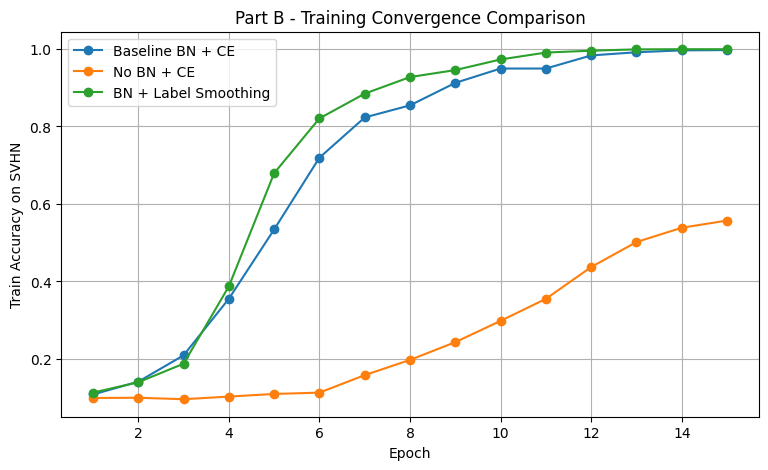

Saved: /content/q1_part_a_outputs/part_b/part_b_train_accuracy_comparison.png


In [ ]:


plt.figure(figsize=(9, 5))

plt.plot(
    baseline_history_df["epoch"],
    baseline_history_df["train_acc"],
    marker="o",
    label="Baseline BN + CE"
)

plt.plot(
    no_bn_history_df["epoch"],
    no_bn_history_df["train_acc"],
    marker="o",
    label="No BN + CE"
)

plt.plot(
    label_smoothing_history_df["epoch"],
    label_smoothing_history_df["train_acc"],
    marker="o",
    label="BN + Label Smoothing"
)

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy on SVHN")
plt.title("Part B - Training Convergence Comparison")
plt.legend()
plt.grid(True)

train_acc_fig_path = os.path.join(PART_B_DIR, "part_b_train_accuracy_comparison.png")
plt.savefig(train_acc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", train_acc_fig_path)

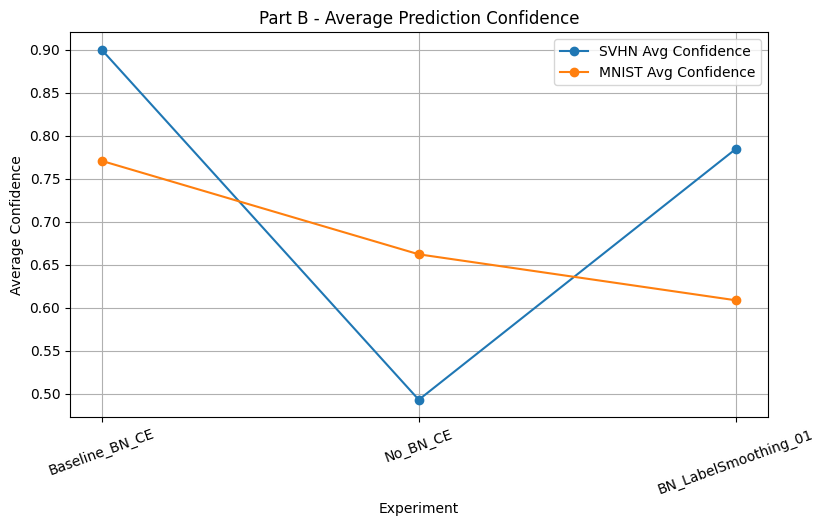

Saved: /content/q1_part_a_outputs/part_b/part_b_confidence_comparison.png


In [ ]:


plt.figure(figsize=(9, 5))

for domain in ["SVHN", "MNIST"]:
    subset_df = confidence_df[confidence_df["test_domain"] == domain]

    plt.plot(
        subset_df["experiment"],
        subset_df["avg_confidence"],
        marker="o",
        label=f"{domain} Avg Confidence"
    )

plt.xlabel("Experiment")
plt.ylabel("Average Confidence")
plt.title("Part B - Average Prediction Confidence")
plt.xticks(rotation=20)
plt.legend()
plt.grid(True)

confidence_fig_path = os.path.join(PART_B_DIR, "part_b_confidence_comparison.png")
plt.savefig(confidence_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", confidence_fig_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمودارهای بخش ب</h3>

<p>
نمودارهای دقت و خطا نشان می‌دهند که مدل بدون Batch Normalization هم در دامنه منبع و هم در دامنه هدف ضعیف‌تر از دو مدل دیگر عمل کرده است. این مدل نه‌تنها دقت پایین‌تری دارد، بلکه روند همگرایی آن نیز کندتر است. بنابراین حذف BN باعث underfitting و ناپایداری آموزش شده است.
</p>

<p>
مدل دارای Label Smoothing روی MNIST عملکرد بهتری نسبت به مدل پایه دارد و در عین حال confidence پیش‌بینی‌های اشتباه را کاهش می‌دهد. این نکته مهم است، زیرا در شرایط domain shift فقط دقت مهم نیست؛ بلکه میزان اطمینان مدل در تصمیم‌های اشتباه نیز اهمیت دارد. کاهش confidence در خطاها نشان می‌دهد که مدل کمتر با اطمینان افراطی تصمیم‌گیری می‌کند.
</p>

</div>

In [ ]:


import os
import time
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

NUM_WORKERS = 0

PART_C_DIR = os.path.join(OUTPUT_DIR, "part_c")
os.makedirs(PART_C_DIR, exist_ok=True)

EPOCHS_C = 15
LR_C = 1e-3
WEIGHT_DECAY_C = 5e-4

print("Part C output directory:", PART_C_DIR)
print("Device:", device)

NameError: name 'OUTPUT_DIR' is not defined

In [ ]:


import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm


DATA_ROOT = "/content/data"
OUTPUT_DIR = "/content/q1_part_a_outputs"

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


NUM_WORKERS = 0
BATCH_SIZE = 128


PART_C_DIR = os.path.join(OUTPUT_DIR, "part_c")
os.makedirs(PART_C_DIR, exist_ok=True)

EPOCHS_C = 15
LR_C = 1e-3
WEIGHT_DECAY_C = 5e-4

print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Part C output directory:", PART_C_DIR)

Device: cpu
DATA_ROOT: /content/data
OUTPUT_DIR: /content/q1_part_a_outputs
Part C output directory: /content/q1_part_a_outputs/part_c


In [ ]:
needed_vars = [
    "svhn_train",
    "svhn_test_loader",
    "mnist_test_loader",
    "ResNet18Small",
    "train_one_epoch",
    "evaluate",
    "history_df"
]

for v in needed_vars:
    print(v, "exists" if v in globals() else "MISSING")

svhn_train MISSING
svhn_test_loader MISSING
mnist_test_loader MISSING
ResNet18Small MISSING
train_one_epoch MISSING
evaluate MISSING
history_df MISSING


In [ ]:


svhn_augmented_transform = transforms.Compose([
    transforms.Resize((32, 32)),

    transforms.RandomCrop(size=32, padding=4, padding_mode="edge"),

    transforms.RandomRotation(degrees=10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.10, 0.10),
        scale=(0.90, 1.10),
        shear=5
    ),

    transforms.ColorJitter(
        brightness=0.30,
        contrast=0.30,
        saturation=0.20
    ),


    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])



print("SVHN augmented transform is ready.")

SVHN augmented transform is ready.


In [ ]:


svhn_train_augmented_full = datasets.SVHN(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=svhn_augmented_transform
)


if isinstance(svhn_train, Subset):
    svhn_train_augmented = Subset(
        svhn_train_augmented_full,
        svhn_train.indices
    )
    print("Using the same subset indices as Part A.")
else:
    svhn_train_augmented = svhn_train_augmented_full
    print("Using full SVHN training set.")

svhn_train_augmented_loader = DataLoader(
    svhn_train_augmented,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print("Augmented SVHN train size:", len(svhn_train_augmented))
print("Augmented train batches:", len(svhn_train_augmented_loader))

100%|██████████| 182M/182M [00:15<00:00, 11.8MB/s]


NameError: name 'svhn_train' is not defined

In [ ]:

USE_SUBSET = True
SVHN_TRAIN_SUBSET = 5000
SVHN_TEST_SUBSET = 1000
MNIST_TEST_SUBSET = 1000


def get_dataset_labels(dataset):
    """
    Extract labels from torchvision datasets.
    SVHN uses .labels
    MNIST uses .targets
    """
    if hasattr(dataset, "labels"):
        labels = dataset.labels
    elif hasattr(dataset, "targets"):
        labels = dataset.targets
    else:
        raise ValueError("Dataset has no labels or targets attribute.")

    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()
    else:
        labels = np.array(labels)

    return labels.astype(int)


def make_balanced_subset(dataset, n_samples, n_classes=10, seed=42):
    labels = get_dataset_labels(dataset)
    rng = np.random.default_rng(seed)

    indices = []
    per_class = n_samples // n_classes
    remainder = n_samples % n_classes

    for cls in range(n_classes):
        cls_indices = np.where(labels == cls)[0]
        n_take = per_class + (1 if cls < remainder else 0)
        n_take = min(n_take, len(cls_indices))

        selected = rng.choice(cls_indices, size=n_take, replace=False)
        indices.extend(selected.tolist())

    rng.shuffle(indices)
    return Subset(dataset, indices)



svhn_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5))
])

mnist_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5))
])



svhn_train_augmented_full = datasets.SVHN(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=svhn_augmented_transform
)

svhn_test_full = datasets.SVHN(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=svhn_transform
)

mnist_test_full = datasets.MNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=mnist_transform
)



if USE_SUBSET:
    svhn_train_augmented = make_balanced_subset(
        svhn_train_augmented_full,
        SVHN_TRAIN_SUBSET,
        seed=SEED
    )

    svhn_test = make_balanced_subset(
        svhn_test_full,
        SVHN_TEST_SUBSET,
        seed=SEED
    )

    mnist_test = make_balanced_subset(
        mnist_test_full,
        MNIST_TEST_SUBSET,
        seed=SEED
    )

    print("Using balanced subsets for Part C.")
else:
    svhn_train_augmented = svhn_train_augmented_full
    svhn_test = svhn_test_full
    mnist_test = mnist_test_full

    print("Using full datasets for Part C.")



pin_memory = True if torch.cuda.is_available() else False

svhn_train_augmented_loader = DataLoader(
    svhn_train_augmented,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

svhn_test_loader = DataLoader(
    svhn_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

mnist_test_loader = DataLoader(
    mnist_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("Augmented SVHN train size:", len(svhn_train_augmented))
print("SVHN test size:", len(svhn_test))
print("MNIST test size:", len(mnist_test))

print("Augmented train batches:", len(svhn_train_augmented_loader))
print("SVHN test batches:", len(svhn_test_loader))
print("MNIST test batches:", len(mnist_test_loader))

100%|██████████| 64.3M/64.3M [00:06<00:00, 10.5MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 53.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 58.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 51.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.73MB/s]

Using balanced subsets for Part C.
Augmented SVHN train size: 5000
SVHN test size: 1000
MNIST test size: 1000
Augmented train batches: 40
SVHN test batches: 8
MNIST test batches: 8


In [ ]:
needed_vars = [
    "svhn_train_augmented_loader",
    "svhn_test_loader",
    "mnist_test_loader",
    "ResNet18Small",
    "train_one_epoch",
    "evaluate",
    "history_df"
]

for v in needed_vars:
    print(v, "exists" if v in globals() else "MISSING")

svhn_train_augmented_loader exists
svhn_test_loader exists
mnist_test_loader exists
ResNet18Small MISSING
train_one_epoch MISSING
evaluate MISSING
history_df MISSING


In [ ]:


import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from tqdm.auto import tqdm

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, use_bn=True):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(planes) if use_bn else nn.Identity()

        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(planes) if use_bn else nn.Identity()

        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes * self.expansion) if use_bn else nn.Identity()
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


class ResNet18Small(nn.Module):
    """
    Manual ResNet18 adapted for 32x32 digit images.
    Block configuration: [2, 2, 2, 2]
    """

    def __init__(self, num_classes=10, use_bn=True):
        super().__init__()

        self.in_planes = 64
        self.use_bn = use_bn

        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64) if use_bn else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)

        layers = []
        for s in strides:
            layers.append(
                BasicBlock(
                    in_planes=self.in_planes,
                    planes=planes,
                    stride=s,
                    use_bn=self.use_bn
                )
            )
            self.in_planes = planes * BasicBlock.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out


dummy_model = ResNet18Small(num_classes=10, use_bn=True).to(device)
dummy_input = torch.randn(2, 3, 32, 32).to(device)
dummy_output = dummy_model(dummy_input)

print("Model output shape:", dummy_output.shape)

Model output shape: torch.Size([2, 10])


In [ ]:


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        progress_bar.set_postfix({
            "loss": running_loss / total,
            "acc": correct / total
        })

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    eval_loss = running_loss / total
    eval_acc = correct / total

    return eval_loss, eval_acc


print("train_one_epoch and evaluate functions are ready.")

train_one_epoch and evaluate functions are ready.


In [ ]:


history_data = [
    [1,  2.410196, 0.1084, 2.325137, 0.126, 2.457773, 0.092],
    [2,  2.292855, 0.1414, 2.369107, 0.176, 3.832498, 0.100],
    [3,  2.181357, 0.2094, 2.196684, 0.270, 2.470935, 0.144],
    [4,  1.823407, 0.3554, 2.032302, 0.364, 3.559235, 0.124],
    [5,  1.406002, 0.5342, 1.106063, 0.628, 1.764456, 0.455],
    [6,  0.837274, 0.7194, 0.927622, 0.674, 1.857331, 0.463],
    [7,  0.542831, 0.8232, 0.737091, 0.747, 1.488888, 0.522],
    [8,  0.445606, 0.8544, 0.582073, 0.793, 2.647536, 0.462],
    [9,  0.283483, 0.9124, 0.491842, 0.835, 1.254267, 0.582],
    [10, 0.178604, 0.9494, 0.447875, 0.863, 1.287681, 0.607],
    [11, 0.171967, 0.9494, 0.465853, 0.853, 1.390913, 0.604],
    [12, 0.083508, 0.9832, 0.444215, 0.859, 1.399689, 0.592],
    [13, 0.057091, 0.9914, 0.450596, 0.858, 1.309674, 0.603],
    [14, 0.041847, 0.9962, 0.457215, 0.856, 1.357288, 0.590],
    [15, 0.037808, 0.9970, 0.453495, 0.858, 1.350559, 0.592],
]

history_df = pd.DataFrame(
    history_data,
    columns=[
        "epoch",
        "train_loss",
        "train_acc",
        "svhn_test_loss",
        "svhn_test_acc",
        "mnist_test_loss",
        "mnist_test_acc"
    ]
)

baseline_history_df = history_df.copy()
baseline_history_df["experiment"] = "Baseline_BN_CE"

history_df

,epoch,train_loss,train_acc,svhn_test_loss,svhn_test_acc,mnist_test_loss,mnist_test_acc
0,1,2.410196,0.1084,2.325137,0.126,2.457773,0.092
1,2,2.292855,0.1414,2.369107,0.176,3.832498,0.100
2,3,2.181357,0.2094,2.196684,0.270,2.470935,0.144
3,4,1.823407,0.3554,2.032302,0.364,3.559235,0.124
4,5,1.406002,0.5342,1.106063,0.628,1.764456,0.455
5,6,0.837274,0.7194,0.927622,0.674,1.857331,0.463
6,7,0.542831,0.8232,0.737091,0.747,1.488888,0.522
7,8,0.445606,0.8544,0.582073,0.793,2.647536,0.462
8,9,0.283483,0.9124,0.491842,0.835,1.254267,0.582
9,10,0.178604,0.9494,0.447875,0.863,1.287681,0.607


In [ ]:
needed_vars = [
    "svhn_train_augmented_loader",
    "svhn_test_loader",
    "mnist_test_loader",
    "ResNet18Small",
    "train_one_epoch",
    "evaluate",
    "history_df"
]

for v in needed_vars:
    print(v, "exists" if v in globals() else "MISSING")

svhn_train_augmented_loader exists
svhn_test_loader exists
mnist_test_loader exists
ResNet18Small exists
train_one_epoch exists
evaluate exists
history_df exists


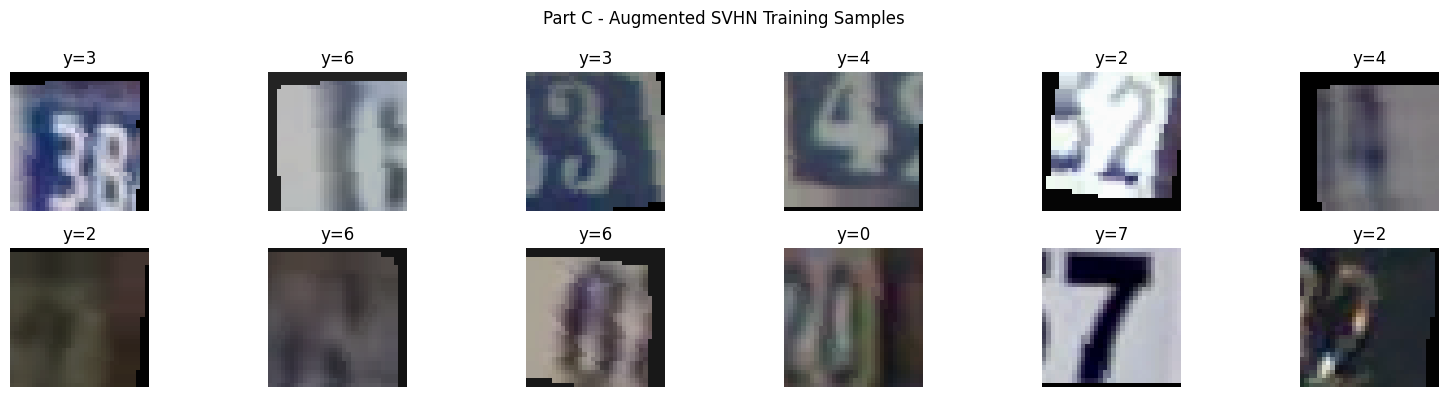

Saved: /content/q1_part_a_outputs/part_c/part_c_augmented_samples.png


In [ ]:


def unnormalize(img):
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)


def show_augmented_batch(loader, title="Augmented SVHN Samples", n=12):
    images, labels = next(iter(loader))

    images = images[:n]
    labels = labels[:n]

    plt.figure(figsize=(16, 4))

    for i in range(n):
        img = unnormalize(images[i]).permute(1, 2, 0).cpu().numpy()

        plt.subplot(2, n // 2, i + 1)
        plt.imshow(img)
        plt.title(f"y={labels[i].item()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()

    fig_path = os.path.join(PART_C_DIR, "part_c_augmented_samples.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)


show_augmented_batch(
    svhn_train_augmented_loader,
    title="Part C - Augmented SVHN Training Samples",
    n=12
)

In [ ]:


def run_part_c_experiment(
    experiment_name,
    train_loader,
    epochs=15,
    lr=1e-3,
    weight_decay=5e-4
):
    print("=" * 80)
    print(f"Starting Part C experiment: {experiment_name}")
    print("=" * 80)

    set_seed(SEED)

    model_aug = ResNet18Small(num_classes=10, use_bn=True).to(device)

    criterion_aug = nn.CrossEntropyLoss()

    optimizer_aug = optim.AdamW(
        model_aug.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler_aug = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_aug,
        T_max=epochs
    )

    history_aug = []

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(
            model=model_aug,
            loader=train_loader,
            criterion=criterion_aug,
            optimizer=optimizer_aug,
            device=device
        )

        svhn_test_loss, svhn_test_acc = evaluate(
            model=model_aug,
            loader=svhn_test_loader,
            criterion=criterion_aug,
            device=device
        )

        mnist_test_loss, mnist_test_acc = evaluate(
            model=model_aug,
            loader=mnist_test_loader,
            criterion=criterion_aug,
            device=device
        )

        scheduler_aug.step()

        row = {
            "experiment": experiment_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "svhn_test_loss": svhn_test_loss,
            "svhn_test_acc": svhn_test_acc,
            "mnist_test_loss": mnist_test_loss,
            "mnist_test_acc": mnist_test_acc,
            "lr": optimizer_aug.param_groups[0]["lr"],
            "epoch_time_sec": time.time() - epoch_start
        }

        history_aug.append(row)

        print(
            f"Epoch [{epoch:02d}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"SVHN Test Acc: {svhn_test_acc:.4f} | "
            f"MNIST Test Acc: {mnist_test_acc:.4f} | "
            f"Time: {row['epoch_time_sec']:.1f}s"
        )

    total_time = time.time() - start_time
    print(f"Total time for {experiment_name}: {total_time / 60:.2f} minutes")

    history_aug_df = pd.DataFrame(history_aug)

    history_path = os.path.join(PART_C_DIR, f"{experiment_name}_history.csv")
    history_aug_df.to_csv(history_path, index=False)

    model_path = os.path.join(PART_C_DIR, f"{experiment_name}_model.pth")
    torch.save({
        "experiment_name": experiment_name,
        "model_state_dict": model_aug.state_dict(),
        "history": history_aug,
        "config": {
            "augmentation": "RandomCrop + RandomRotation + RandomAffine + ColorJitter",
            "epochs": epochs,
            "lr": lr,
            "weight_decay": weight_decay
        }
    }, model_path)

    print("Saved history:", history_path)
    print("Saved model:", model_path)

    return model_aug, history_aug_df

In [ ]:


model_augmented, augmented_history_df = run_part_c_experiment(
    experiment_name="SVHN_Augmented",
    train_loader=svhn_train_augmented_loader,
    epochs=EPOCHS_C,
    lr=LR_C,
    weight_decay=WEIGHT_DECAY_C
)

augmented_history_df

Starting Part C experiment: SVHN_Augmented


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [01/15] | Train Loss: 2.4518 | Train Acc: 0.1052 | SVHN Test Acc: 0.1140 | MNIST Test Acc: 0.1000 | Time: 439.4s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [02/15] | Train Loss: 2.3260 | Train Acc: 0.1056 | SVHN Test Acc: 0.1010 | MNIST Test Acc: 0.1020 | Time: 427.1s


...

Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [14/15] | Train Loss: 0.5243 | Train Acc: 0.8344 | SVHN Test Acc: 0.8850 | MNIST Test Acc: 0.5460 | Time: 441.7s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [15/15] | Train Loss: 0.5085 | Train Acc: 0.8386 | SVHN Test Acc: 0.8880 | MNIST Test Acc: 0.5460 | Time: 427.1s
Total time for SVHN_Augmented: 108.51 minutes
Saved history: /content/q1_part_a_outputs/part_c/SVHN_Augmented_history.csv
Saved model: /content/q1_part_a_outputs/part_c/SVHN_Augmented_model.pth


,experiment,epoch,train_loss,train_acc,svhn_test_loss,svhn_test_acc,mnist_test_loss,mnist_test_acc,lr,epoch_time_sec
0,SVHN_Augmented,1,2.451797,0.1052,2.364711,0.114,2.386111,0.100,0.000989,439.397213
1,SVHN_Augmented,2,2.325958,0.1056,2.330661,0.101,2.396425,0.102,0.000957,427.087294
2,SVHN_Augmented,3,2.308249,0.1224,2.284128,0.146,2.271131,0.110,0.000905,425.709866
3,SVHN_Augmented,4,2.261824,0.1526,2.215915,0.159,2.240209,0.172,0.000835,426.875179
4,SVHN_Augmented,5,2.162101,0.2128,1.943100,0.329,3.320034,0.119,0.000750,429.136019
5,SVHN_Augmented,6,1.980325,0.2992,1.697730,0.405,2.352620,0.117,0.000655,425.880144
6,SVHN_Augmented,7,1.522950,0.4840,1.398252,0.564,2.093390,0.304,0.000552,427.528652
7,SVHN_Augmented,8,1.153750,0.6094,0.817249,0.751,1.898858,0.331,0.000448,433.827883
8,SVHN_Augmented,9,0.923527,0.6982,0.682866,0.784,2.015058,0.326,0.000345,435.010119
9,SVHN_Augmented,10,0.783317,0.7426,0.558335,0.833,1.600102,0.449,0.000250,438.931786


In [ ]:


try:
    baseline_for_c_df = baseline_history_df.copy()
except NameError:
    baseline_for_c_df = history_df.copy()

baseline_final = baseline_for_c_df.iloc[-1]
augmented_final = augmented_history_df.iloc[-1]

part_c_summary_df = pd.DataFrame([
    {
        "experiment": "Baseline_BN_CE",
        "train_transform": "Normal",
        "final_train_loss": baseline_final["train_loss"],
        "final_train_acc": baseline_final["train_acc"],
        "final_svhn_test_loss": baseline_final["svhn_test_loss"],
        "final_svhn_test_acc": baseline_final["svhn_test_acc"],
        "final_mnist_test_loss": baseline_final["mnist_test_loss"],
        "final_mnist_test_acc": baseline_final["mnist_test_acc"],
        "domain_gap_svhn_minus_mnist": baseline_final["svhn_test_acc"] - baseline_final["mnist_test_acc"]
    },
    {
        "experiment": "SVHN_Augmented",
        "train_transform": "Safe Augmentation",
        "final_train_loss": augmented_final["train_loss"],
        "final_train_acc": augmented_final["train_acc"],
        "final_svhn_test_loss": augmented_final["svhn_test_loss"],
        "final_svhn_test_acc": augmented_final["svhn_test_acc"],
        "final_mnist_test_loss": augmented_final["mnist_test_loss"],
        "final_mnist_test_acc": augmented_final["mnist_test_acc"],
        "domain_gap_svhn_minus_mnist": augmented_final["svhn_test_acc"] - augmented_final["mnist_test_acc"]
    }
])

summary_path = os.path.join(PART_C_DIR, "part_c_final_summary.csv")
part_c_summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
part_c_summary_df

Saved: /content/q1_part_a_outputs/part_c/part_c_final_summary.csv


,experiment,train_transform,final_train_loss,final_train_acc,final_svhn_test_loss,final_svhn_test_acc,final_mnist_test_loss,final_mnist_test_acc,domain_gap_svhn_minus_mnist
0,Baseline_BN_CE,Normal,0.037808,0.9970,0.453495,0.858,1.350559,0.592,0.266
1,SVHN_Augmented,Safe Augmentation,0.508467,0.8386,0.379584,0.888,1.339428,0.546,0.342


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل عددی بخش ج: اثر افزایش داده</h3>

<p>
در این بخش مدل با داده‌های افزایش‌یافته SVHN آموزش داده شد. نتیجه نشان می‌دهد که augmentation توانسته عملکرد مدل روی دامنه منبع را بهتر کند؛ زیرا دقت SVHN از 0.858 در مدل پایه به 0.888 در مدل augmented افزایش یافته است. بنابراین افزایش داده برای پوشش بهتر تنوع درون دامنه SVHN مفید بوده است.
</p>

<p>
با این حال، دقت MNIST از 0.592 به 0.546 کاهش یافته و شکاف دامنه از 0.266 به 0.342 افزایش پیدا کرده است. بنابراین در این آزمایش، augmentation انتخاب‌شده باعث بهبود تعمیم بین‌دامنه‌ای نشده است. به بیان دیگر، این تبدیلات بیشتر تنوع داخل SVHN را افزایش داده‌اند، اما نتوانسته‌اند فاصله ظاهری و آماری بین SVHN و MNIST را کاهش دهند.
</p>

</div>

In [ ]:


baseline_svhn_acc = baseline_final["svhn_test_acc"]
baseline_mnist_acc = baseline_final["mnist_test_acc"]

aug_svhn_acc = augmented_final["svhn_test_acc"]
aug_mnist_acc = augmented_final["mnist_test_acc"]

svhn_change = aug_svhn_acc - baseline_svhn_acc
mnist_change = aug_mnist_acc - baseline_mnist_acc

baseline_gap = baseline_svhn_acc - baseline_mnist_acc
aug_gap = aug_svhn_acc - aug_mnist_acc
gap_change = aug_gap - baseline_gap

print("SVHN accuracy change:", round(svhn_change, 4))
print("MNIST accuracy change:", round(mnist_change, 4))
print("Baseline domain gap:", round(baseline_gap, 4))
print("Augmented domain gap:", round(aug_gap, 4))
print("Domain gap change:", round(gap_change, 4))

if mnist_change > 0:
    print("Result: Augmentation improved target-domain generalization on MNIST.")
else:
    print("Result: Augmentation did not improve MNIST accuracy. The augmentation strength may need adjustment.")

if gap_change < 0:
    print("Result: Domain gap decreased after augmentation.")
else:
    print("Result: Domain gap did not decrease after augmentation.")

SVHN accuracy change: 0.03
MNIST accuracy change: -0.046
Baseline domain gap: 0.266
Augmented domain gap: 0.342
Domain gap change: 0.076
Result: Augmentation did not improve MNIST accuracy. The augmentation strength may need adjustment.
Result: Domain gap did not decrease after augmentation.


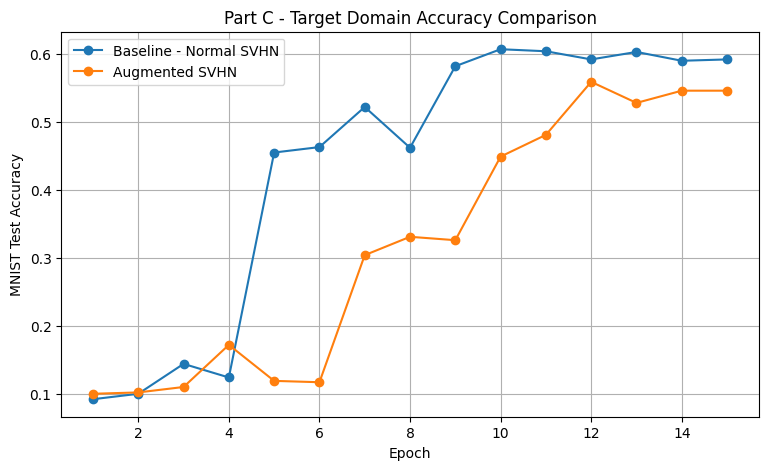

Saved: /content/q1_part_a_outputs/part_c/part_c_mnist_accuracy_comparison.png


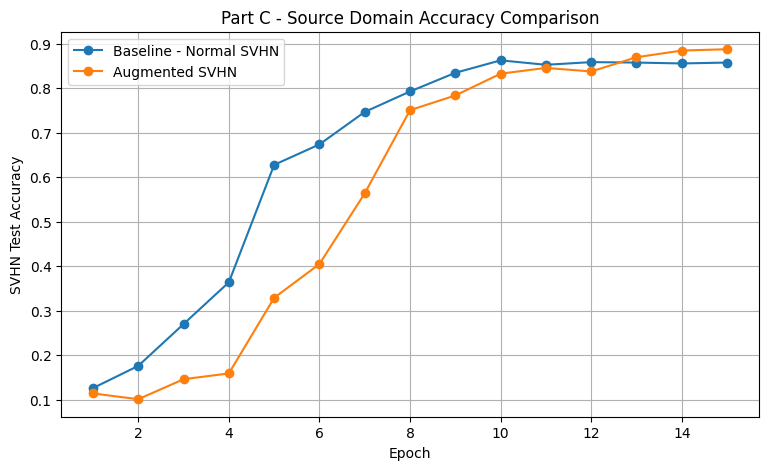

Saved: /content/q1_part_a_outputs/part_c/part_c_svhn_accuracy_comparison.png


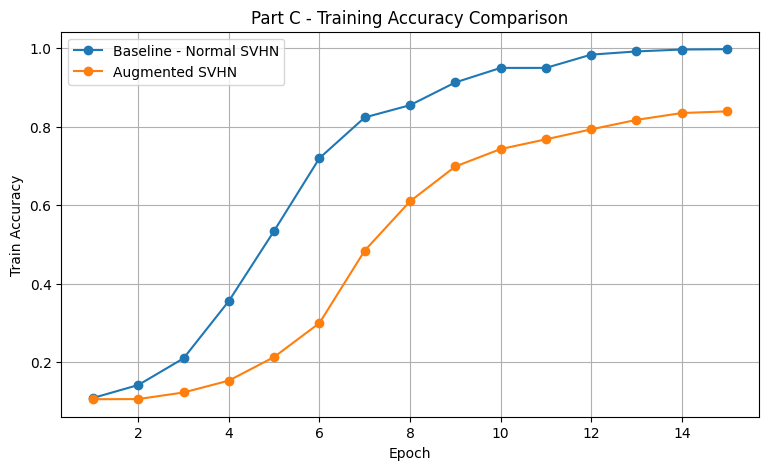

Saved: /content/q1_part_a_outputs/part_c/part_c_train_accuracy_comparison.png


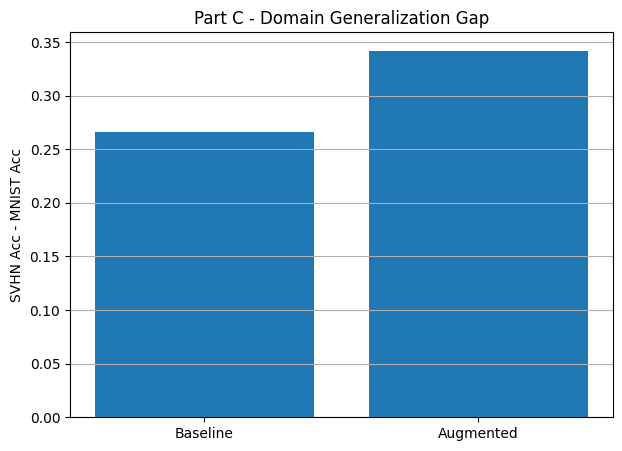

Saved: /content/q1_part_a_outputs/part_c/part_c_domain_gap_comparison.png


,experiment,domain_gap
0,Baseline,0.266
1,Augmented,0.342


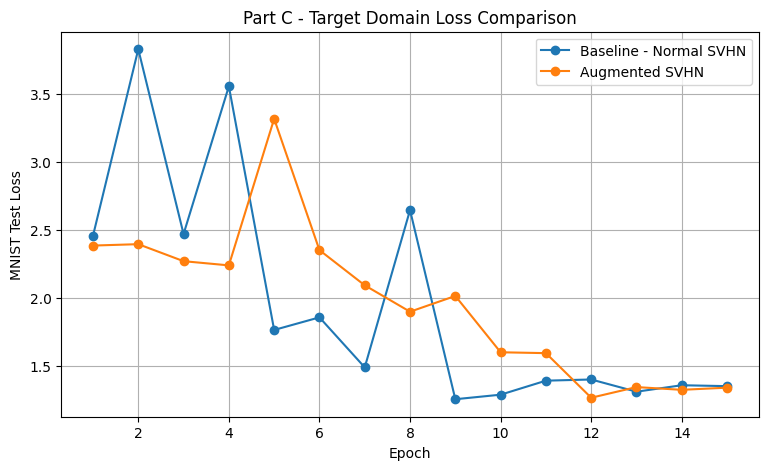

Saved: /content/q1_part_a_outputs/part_c/part_c_mnist_loss_comparison.png


In [ ]:


import os
import pandas as pd
import matplotlib.pyplot as plt

try:
    baseline_for_c_df
except NameError:
    baseline_for_c_df = baseline_history_df.copy() if "baseline_history_df" in globals() else history_df.copy()

try:
    PART_C_DIR
except NameError:
    PART_C_DIR = "/content/q1_part_a_outputs/part_c"
    os.makedirs(PART_C_DIR, exist_ok=True)


plt.figure(figsize=(9, 5))

plt.plot(
    baseline_for_c_df["epoch"],
    baseline_for_c_df["mnist_test_acc"],
    marker="o",
    label="Baseline - Normal SVHN"
)

plt.plot(
    augmented_history_df["epoch"],
    augmented_history_df["mnist_test_acc"],
    marker="o",
    label="Augmented SVHN"
)

plt.xlabel("Epoch")
plt.ylabel("MNIST Test Accuracy")
plt.title("Part C - Target Domain Accuracy Comparison")
plt.legend()
plt.grid(True)

mnist_acc_path = os.path.join(PART_C_DIR, "part_c_mnist_accuracy_comparison.png")
plt.savefig(mnist_acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", mnist_acc_path)



plt.figure(figsize=(9, 5))

plt.plot(
    baseline_for_c_df["epoch"],
    baseline_for_c_df["svhn_test_acc"],
    marker="o",
    label="Baseline - Normal SVHN"
)

plt.plot(
    augmented_history_df["epoch"],
    augmented_history_df["svhn_test_acc"],
    marker="o",
    label="Augmented SVHN"
)

plt.xlabel("Epoch")
plt.ylabel("SVHN Test Accuracy")
plt.title("Part C - Source Domain Accuracy Comparison")
plt.legend()
plt.grid(True)

svhn_acc_path = os.path.join(PART_C_DIR, "part_c_svhn_accuracy_comparison.png")
plt.savefig(svhn_acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", svhn_acc_path)



plt.figure(figsize=(9, 5))

plt.plot(
    baseline_for_c_df["epoch"],
    baseline_for_c_df["train_acc"],
    marker="o",
    label="Baseline - Normal SVHN"
)

plt.plot(
    augmented_history_df["epoch"],
    augmented_history_df["train_acc"],
    marker="o",
    label="Augmented SVHN"
)

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy")
plt.title("Part C - Training Accuracy Comparison")
plt.legend()
plt.grid(True)

train_acc_path = os.path.join(PART_C_DIR, "part_c_train_accuracy_comparison.png")
plt.savefig(train_acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", train_acc_path)



baseline_final = baseline_for_c_df.iloc[-1]
augmented_final = augmented_history_df.iloc[-1]

gap_df = pd.DataFrame({
    "experiment": ["Baseline", "Augmented"],
    "domain_gap": [
        baseline_final["svhn_test_acc"] - baseline_final["mnist_test_acc"],
        augmented_final["svhn_test_acc"] - augmented_final["mnist_test_acc"]
    ]
})

plt.figure(figsize=(7, 5))
plt.bar(gap_df["experiment"], gap_df["domain_gap"])

plt.ylabel("SVHN Acc - MNIST Acc")
plt.title("Part C - Domain Generalization Gap")
plt.grid(axis="y")

gap_path = os.path.join(PART_C_DIR, "part_c_domain_gap_comparison.png")
plt.savefig(gap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", gap_path)
display(gap_df)

plt.figure(figsize=(9, 5))

plt.plot(
    baseline_for_c_df["epoch"],
    baseline_for_c_df["mnist_test_loss"],
    marker="o",
    label="Baseline - Normal SVHN"
)

plt.plot(
    augmented_history_df["epoch"],
    augmented_history_df["mnist_test_loss"],
    marker="o",
    label="Augmented SVHN"
)

plt.xlabel("Epoch")
plt.ylabel("MNIST Test Loss")
plt.title("Part C - Target Domain Loss Comparison")
plt.legend()
plt.grid(True)

mnist_loss_path = os.path.join(PART_C_DIR, "part_c_mnist_loss_comparison.png")
plt.savefig(mnist_loss_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", mnist_loss_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمودارهای بخش ج</h3>

<p>
در نمودار دقت MNIST مشاهده می‌شود که مدل پایه در بیشتر epochها عملکرد بهتری نسبت به مدل آموزش‌دیده با داده‌های افزایش‌یافته دارد. این موضوع نشان می‌دهد که augmentation استفاده‌شده برای انتقال به دامنه MNIST مناسب نبوده است. در مقابل، نمودار دقت SVHN نشان می‌دهد که مدل augmented در epochهای پایانی عملکرد بهتری روی دامنه منبع دارد.
</p>

<p>
نمودار دقت آموزش نیز نشان می‌دهد که مدل augmented کندتر همگرا شده و دقت آموزش پایین‌تری دارد. این رفتار طبیعی است، زیرا augmentation داده‌های آموزشی را سخت‌تر می‌کند و مانند یک regularizer مانع حفظ کردن سریع نمونه‌ها می‌شود. با این حال، افزایش Domain Gap نشان می‌دهد که regularization ایجادشده الزاماً به معنی یادگیری ویژگی‌های invariant بین دامنه‌ها نیست.
</p>

</div>

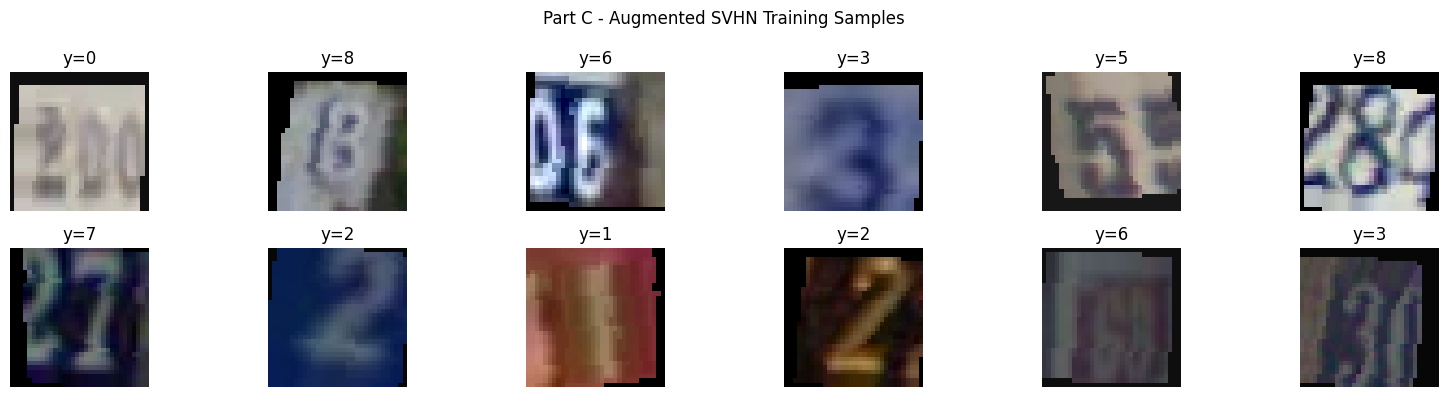

Saved: /content/q1_part_a_outputs/part_c/part_c_augmented_samples.png


In [ ]:
def unnormalize(img):
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)


def show_augmented_batch(loader, title="Augmented SVHN Samples", n=12):
    images, labels = next(iter(loader))

    images = images[:n]
    labels = labels[:n]

    plt.figure(figsize=(16, 4))

    for i in range(n):
        img = unnormalize(images[i]).permute(1, 2, 0).cpu().numpy()

        plt.subplot(2, n // 2, i + 1)
        plt.imshow(img)
        plt.title(f"y={labels[i].item()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()

    fig_path = os.path.join(PART_C_DIR, "part_c_augmented_samples.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)


show_augmented_batch(
    svhn_train_augmented_loader,
    title="Part C - Augmented SVHN Training Samples",
    n=12
)

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm


SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


DATA_ROOT = "/content/data"
OUTPUT_DIR = "/content/q1_part_d_outputs"
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


NUM_WORKERS = 0

USE_SUBSET_D = True
SVHN_TRAIN_SUBSET_D = 3000
SVHN_TEST_SUBSET_D = 1000
MNIST_TEST_SUBSET_D = 1000

BATCH_SIZE_D = 64

EPOCHS_D = 8

print("OUTPUT_DIR:", OUTPUT_DIR)
print("USE_SUBSET_D:", USE_SUBSET_D)
print("EPOCHS_D:", EPOCHS_D)
print("BATCH_SIZE_D:", BATCH_SIZE_D)

Device: cpu
OUTPUT_DIR: /content/q1_part_d_outputs
USE_SUBSET_D: True
EPOCHS_D: 8
BATCH_SIZE_D: 64


In [ ]:

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

svhn_d_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

mnist_d_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


def get_dataset_labels(dataset):
    if hasattr(dataset, "labels"):
        labels = dataset.labels
    elif hasattr(dataset, "targets"):
        labels = dataset.targets
    else:
        raise ValueError("Dataset has no labels or targets attribute.")

    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()
    else:
        labels = np.array(labels)

    return labels.astype(int)


def make_balanced_subset(dataset, n_samples, n_classes=10, seed=42):
    labels = get_dataset_labels(dataset)
    rng = np.random.default_rng(seed)

    indices = []
    per_class = n_samples // n_classes
    remainder = n_samples % n_classes

    for cls in range(n_classes):
        cls_indices = np.where(labels == cls)[0]
        n_take = per_class + (1 if cls < remainder else 0)
        n_take = min(n_take, len(cls_indices))

        selected = rng.choice(cls_indices, size=n_take, replace=False)
        indices.extend(selected.tolist())

    rng.shuffle(indices)
    return Subset(dataset, indices)


svhn_train_full_d = datasets.SVHN(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=svhn_d_transform
)

svhn_test_full_d = datasets.SVHN(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=svhn_d_transform
)

mnist_test_full_d = datasets.MNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=mnist_d_transform
)

if USE_SUBSET_D:
    svhn_train_d = make_balanced_subset(
        svhn_train_full_d,
        SVHN_TRAIN_SUBSET_D,
        seed=SEED
    )

    svhn_test_d = make_balanced_subset(
        svhn_test_full_d,
        SVHN_TEST_SUBSET_D,
        seed=SEED
    )

    mnist_test_d = make_balanced_subset(
        mnist_test_full_d,
        MNIST_TEST_SUBSET_D,
        seed=SEED
    )

    print("Using balanced subsets for Part D.")
else:
    svhn_train_d = svhn_train_full_d
    svhn_test_d = svhn_test_full_d
    mnist_test_d = mnist_test_full_d

pin_memory = True if torch.cuda.is_available() else False

svhn_train_loader_d = DataLoader(
    svhn_train_d,
    batch_size=BATCH_SIZE_D,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

svhn_test_loader_d = DataLoader(
    svhn_test_d,
    batch_size=BATCH_SIZE_D,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

mnist_test_loader_d = DataLoader(
    mnist_test_d,
    batch_size=BATCH_SIZE_D,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("SVHN train size:", len(svhn_train_d))
print("SVHN test size:", len(svhn_test_d))
print("MNIST test size:", len(mnist_test_d))
print("Train batches:", len(svhn_train_loader_d))
print("SVHN test batches:", len(svhn_test_loader_d))
print("MNIST test batches:", len(mnist_test_loader_d))

x, y = next(iter(svhn_train_loader_d))
print("Batch image shape:", x.shape)
print("Batch label shape:", y.shape)

Using balanced subsets for Part D.
SVHN train size: 3000
SVHN test size: 1000
MNIST test size: 1000
Train batches: 47
SVHN test batches: 16
MNIST test batches: 16
Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])


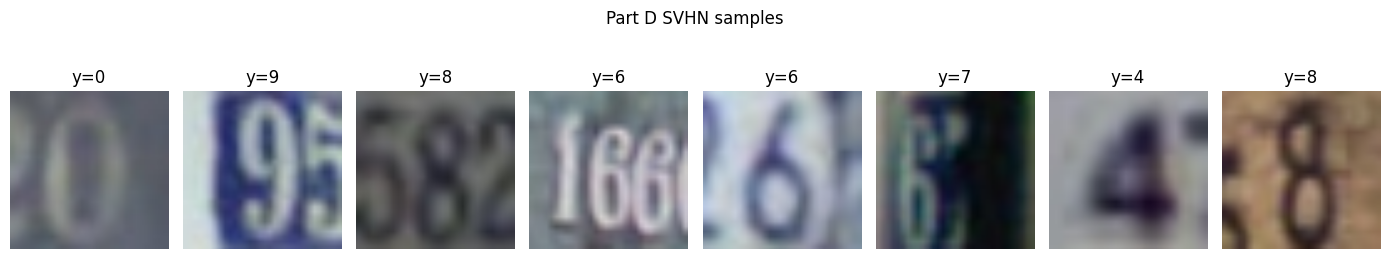

Saved: /content/q1_part_d_outputs/part_d_svhn_samples.png


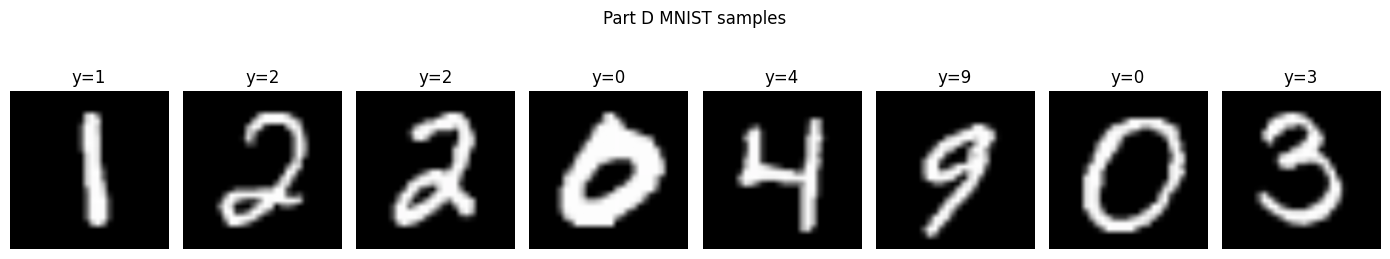

Saved: /content/q1_part_d_outputs/part_d_mnist_samples.png


In [ ]:


def denormalize_imagenet(img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img.cpu() * std + mean
    return img.clamp(0, 1)


def show_batch_d(loader, title, n=8):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]

    plt.figure(figsize=(14, 3))

    for i in range(n):
        img = denormalize_imagenet(images[i]).permute(1, 2, 0).numpy()
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f"y={labels[i].item()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    fig_path = os.path.join(OUTPUT_DIR, f"{title.replace(' ', '_').lower()}.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)


show_batch_d(svhn_train_loader_d, "Part D SVHN samples", n=8)
show_batch_d(mnist_test_loader_d, "Part D MNIST samples", n=8)

In [ ]:
def train_one_epoch_d(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        progress_bar.set_postfix({
            "loss": running_loss / total,
            "acc": correct / total
        })

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate_d(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    return running_loss / total, correct / total


def count_trainable_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


print("Train/evaluate functions are ready.")

Train/evaluate functions are ready.


In [ ]:
def build_resnet18_random(num_classes=10):
    """
    ResNet18 with random initialization.
    Entire model is trainable.
    """
    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    for p in model.parameters():
        p.requires_grad = True

    return model


def build_resnet18_linear_probe(num_classes=10):
    """
    ImageNet-pretrained ResNet18.
    Backbone is frozen. Only final FC layer is trainable.
    """
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)

    for p in model.parameters():
        p.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, num_classes)

    for p in model.fc.parameters():
        p.requires_grad = True

    return model


def build_resnet18_full_finetune(num_classes=10):
    """
    ImageNet-pretrained ResNet18.
    Entire model is trainable.
    """
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    for p in model.parameters():
        p.requires_grad = True

    return model


# Quick check
tmp_models = {
    "Random_Init": build_resnet18_random(),
    "ImageNet_Linear_Probe": build_resnet18_linear_probe(),
    "ImageNet_Full_Finetune": build_resnet18_full_finetune()
}

for name, m in tmp_models.items():
    trainable, total = count_trainable_parameters(m)
    print(f"{name}: trainable={trainable:,} / total={total:,}")

del tmp_models
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.2MB/s]


Random_Init: trainable=11,181,642 / total=11,181,642
ImageNet_Linear_Probe: trainable=5,130 / total=11,181,642
ImageNet_Full_Finetune: trainable=11,181,642 / total=11,181,642


In [ ]:
def run_part_d_experiment(
    experiment_name,
    model,
    training_strategy,
    initialization,
    epochs=8
):
    print("=" * 90)
    print(f"Experiment: {experiment_name}")
    print(f"Initialization: {initialization}")
    print(f"Training strategy: {training_strategy}")
    print("=" * 90)

    set_seed(SEED)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()


    if training_strategy == "full_finetuning_pretrained":
        backbone_params = []
        fc_params = []

        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if name.startswith("fc."):
                fc_params.append(param)
            else:
                backbone_params.append(param)

        optimizer = optim.AdamW(
            [
                {"params": backbone_params, "lr": 1e-5},
                {"params": fc_params, "lr": 1e-3}
            ],
            weight_decay=1e-4
        )
    else:
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-3,
            weight_decay=1e-4
        )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    trainable, total = count_trainable_parameters(model)

    history = []

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch_d(
            model=model,
            loader=svhn_train_loader_d,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        svhn_test_loss, svhn_test_acc = evaluate_d(
            model=model,
            loader=svhn_test_loader_d,
            criterion=criterion,
            device=device
        )

        mnist_test_loss, mnist_test_acc = evaluate_d(
            model=model,
            loader=mnist_test_loader_d,
            criterion=criterion,
            device=device
        )

        scheduler.step()

        current_lr = optimizer.param_groups[-1]["lr"]

        row = {
            "experiment": experiment_name,
            "initialization": initialization,
            "training_strategy": training_strategy,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "svhn_test_loss": svhn_test_loss,
            "svhn_test_acc": svhn_test_acc,
            "mnist_test_loss": mnist_test_loss,
            "mnist_test_acc": mnist_test_acc,
            "lr": current_lr,
            "trainable_params": trainable,
            "total_params": total,
            "epoch_time_sec": time.time() - epoch_start
        }

        history.append(row)

        print(
            f"Epoch [{epoch:02d}/{epochs}] | "
            f"Train Acc: {train_acc:.4f} | "
            f"SVHN Acc: {svhn_test_acc:.4f} | "
            f"MNIST Acc: {mnist_test_acc:.4f} | "
            f"Time: {row['epoch_time_sec']:.1f}s"
        )

    total_time = time.time() - start_time
    print(f"Total time for {experiment_name}: {total_time / 60:.2f} minutes")

    history_df = pd.DataFrame(history)

    history_path = os.path.join(OUTPUT_DIR, f"{experiment_name}_history.csv")
    history_df.to_csv(history_path, index=False)

    model_path = os.path.join(OUTPUT_DIR, f"{experiment_name}_model.pth")
    torch.save(
        {
            "experiment": experiment_name,
            "initialization": initialization,
            "training_strategy": training_strategy,
            "model_state_dict": model.state_dict(),
            "history": history,
            "config": {
                "epochs": epochs,
                "batch_size": BATCH_SIZE_D,
                "train_subset": SVHN_TRAIN_SUBSET_D if USE_SUBSET_D else "full",
                "svhn_test_subset": SVHN_TEST_SUBSET_D if USE_SUBSET_D else "full",
                "mnist_test_subset": MNIST_TEST_SUBSET_D if USE_SUBSET_D else "full",
                "image_size": "224x224",
                "normalization": "ImageNet"
            }
        },
        model_path
    )

    print("Saved history:", history_path)
    print("Saved model:", model_path)

    return model, history_df

In [ ]:
torch.cuda.empty_cache()

model_random = build_resnet18_random(num_classes=10)

model_random, random_history_df = run_part_d_experiment(
    experiment_name="D_Random_Init_Full_Training",
    model=model_random,
    initialization="Random",
    training_strategy="full_training_random",
    epochs=EPOCHS_D
)

random_history_df

Experiment: D_Random_Init_Full_Training
Initialization: Random
Training strategy: full_training_random


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [01/8] | Train Acc: 0.1063 | SVHN Acc: 0.1050 | MNIST Acc: 0.1000 | Time: 942.8s


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [02/8] | Train Acc: 0.1177 | SVHN Acc: 0.0980 | MNIST Acc: 0.1450 | Time: 934.1s


...

Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [07/8] | Train Acc: 0.1743 | SVHN Acc: 0.1530 | MNIST Acc: 0.1000 | Time: 957.6s


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [08/8] | Train Acc: 0.1963 | SVHN Acc: 0.1610 | MNIST Acc: 0.1800 | Time: 955.8s
Total time for D_Random_Init_Full_Training: 125.75 minutes
Saved history: /content/q1_part_d_outputs/D_Random_Init_Full_Training_history.csv
Saved model: /content/q1_part_d_outputs/D_Random_Init_Full_Training_model.pth


,experiment,initialization,training_strategy,epoch,train_loss,train_acc,svhn_test_loss,svhn_test_acc,mnist_test_loss,mnist_test_acc,lr,trainable_params,total_params,epoch_time_sec
0,D_Random_Init_Full_Training,Random,full_training_random,1,2.423973,0.106333,2.855996,0.105,6.446350,0.100,0.000962,11181642,11181642,942.796453
1,D_Random_Init_Full_Training,Random,full_training_random,2,2.333778,0.117667,2.499933,0.098,2.488849,0.145,0.000854,11181642,11181642,934.098683
2,D_Random_Init_Full_Training,Random,full_training_random,3,2.328460,0.113667,2.451685,0.099,2.520249,0.100,0.000691,11181642,11181642,925.194577
3,D_Random_Init_Full_Training,Random,full_training_random,4,2.307446,0.119000,3.477681,0.102,25.655712,0.100,0.000500,11181642,11181642,932.344700
4,D_Random_Init_Full_Training,Random,full_training_random,5,2.295577,0.121000,2.336404,0.122,4.393983,0.100,0.000309,11181642,11181642,953.684343
5,D_Random_Init_Full_Training,Random,full_training_random,6,2.274979,0.144333,2.393172,0.140,5.960255,0.107,0.000146,11181642,11181642,943.288779
6,D_Random_Init_Full_Training,Random,full_training_random,7,2.240431,0.174333,2.285186,0.153,3.455878,0.100,0.000038,11181642,11181642,957.641399
7,D_Random_Init_Full_Training,Random,full_training_random,8,2.209151,0.196333,2.262146,0.161,2.477282,0.180,0.000000,11181642,11181642,955.834988


In [ ]:
torch.cuda.empty_cache()

model_linear = build_resnet18_linear_probe(num_classes=10)

model_linear, linear_history_df = run_part_d_experiment(
    experiment_name="D_ImageNet_Linear_Probing",
    model=model_linear,
    initialization="ImageNet",
    training_strategy="linear_probing",
    epochs=EPOCHS_D
)

linear_history_df

Experiment: D_ImageNet_Linear_Probing
Initialization: ImageNet
Training strategy: linear_probing


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [01/8] | Train Acc: 0.1533 | SVHN Acc: 0.1700 | MNIST Acc: 0.1840 | Time: 432.4s


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [02/8] | Train Acc: 0.2493 | SVHN Acc: 0.2330 | MNIST Acc: 0.1780 | Time: 438.1s


...

Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [07/8] | Train Acc: 0.4073 | SVHN Acc: 0.3250 | MNIST Acc: 0.3040 | Time: 451.8s


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [08/8] | Train Acc: 0.4173 | SVHN Acc: 0.3180 | MNIST Acc: 0.3100 | Time: 441.3s
Total time for D_ImageNet_Linear_Probing: 58.55 minutes
Saved history: /content/q1_part_d_outputs/D_ImageNet_Linear_Probing_history.csv
Saved model: /content/q1_part_d_outputs/D_ImageNet_Linear_Probing_model.pth


,experiment,initialization,training_strategy,epoch,train_loss,train_acc,svhn_test_loss,svhn_test_acc,mnist_test_loss,mnist_test_acc,lr,trainable_params,total_params,epoch_time_sec
0,D_ImageNet_Linear_Probing,ImageNet,linear_probing,1,2.300004,0.153333,2.230973,0.170,2.269414,0.184,0.000962,5130,11181642,432.366229
1,D_ImageNet_Linear_Probing,ImageNet,linear_probing,2,2.107372,0.249333,2.121898,0.233,2.188260,0.178,0.000854,5130,11181642,438.061810
2,D_ImageNet_Linear_Probing,ImageNet,linear_probing,3,1.971480,0.311000,2.036116,0.295,2.045293,0.293,0.000691,5130,11181642,436.454204
3,D_ImageNet_Linear_Probing,ImageNet,linear_probing,4,1.885591,0.360333,2.013207,0.290,1.969991,0.338,0.000500,5130,11181642,436.589965
4,D_ImageNet_Linear_Probing,ImageNet,linear_probing,5,1.834929,0.390667,1.972809,0.314,1.996349,0.280,0.000309,5130,11181642,436.384993
5,D_ImageNet_Linear_Probing,ImageNet,linear_probing,6,1.801545,0.401000,1.967234,0.327,1.962163,0.318,0.000146,5130,11181642,440.165980
6,D_ImageNet_Linear_Probing,ImageNet,linear_probing,7,1.786248,0.407333,1.958966,0.325,1.964470,0.304,0.000038,5130,11181642,451.820301
7,D_ImageNet_Linear_Probing,ImageNet,linear_probing,8,1.774125,0.417333,1.958947,0.318,1.952416,0.310,0.000000,5130,11181642,441.276466


In [ ]:
torch.cuda.empty_cache()

model_finetune = build_resnet18_full_finetune(num_classes=10)

model_finetune, finetune_history_df = run_part_d_experiment(
    experiment_name="D_ImageNet_Full_Finetuning",
    model=model_finetune,
    initialization="ImageNet",
    training_strategy="full_finetuning_pretrained",
    epochs=EPOCHS_D
)

finetune_history_df

Experiment: D_ImageNet_Full_Finetuning
Initialization: ImageNet
Training strategy: full_finetuning_pretrained


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [01/8] | Train Acc: 0.1887 | SVHN Acc: 0.2320 | MNIST Acc: 0.2560 | Time: 903.6s


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [02/8] | Train Acc: 0.4023 | SVHN Acc: 0.3700 | MNIST Acc: 0.2300 | Time: 907.4s


...

Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [07/8] | Train Acc: 0.8060 | SVHN Acc: 0.6060 | MNIST Acc: 0.3880 | Time: 901.6s


Training:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch [08/8] | Train Acc: 0.8170 | SVHN Acc: 0.6160 | MNIST Acc: 0.3910 | Time: 908.4s
Total time for D_ImageNet_Full_Finetuning: 120.30 minutes
Saved history: /content/q1_part_d_outputs/D_ImageNet_Full_Finetuning_history.csv
Saved model: /content/q1_part_d_outputs/D_ImageNet_Full_Finetuning_model.pth


,experiment,initialization,training_strategy,epoch,train_loss,train_acc,svhn_test_loss,svhn_test_acc,mnist_test_loss,mnist_test_acc,lr,trainable_params,total_params,epoch_time_sec
0,D_ImageNet_Full_Finetuning,ImageNet,full_finetuning_pretrained,1,2.239706,0.188667,2.124714,0.232,2.185336,0.256,0.000962,11181642,11181642,903.604646
1,D_ImageNet_Full_Finetuning,ImageNet,full_finetuning_pretrained,2,1.810820,0.402333,1.810023,0.370,2.023009,0.230,0.000854,11181642,11181642,907.442129
2,D_ImageNet_Full_Finetuning,ImageNet,full_finetuning_pretrained,3,1.412493,0.571667,1.537319,0.504,1.803913,0.341,0.000691,11181642,11181642,893.279593
3,D_ImageNet_Full_Finetuning,ImageNet,full_finetuning_pretrained,4,1.114027,0.679667,1.371726,0.549,1.751770,0.387,0.000500,11181642,11181642,900.822393
4,D_ImageNet_Full_Finetuning,ImageNet,full_finetuning_pretrained,5,0.916930,0.745333,1.253006,0.591,1.706077,0.384,0.000309,11181642,11181642,901.969488
5,D_ImageNet_Full_Finetuning,ImageNet,full_finetuning_pretrained,6,0.798502,0.791333,1.203881,0.594,1.684171,0.383,0.000146,11181642,11181642,901.035076
6,D_ImageNet_Full_Finetuning,ImageNet,full_finetuning_pretrained,7,0.744704,0.806000,1.182056,0.606,1.672105,0.388,0.000038,11181642,11181642,901.582228
7,D_ImageNet_Full_Finetuning,ImageNet,full_finetuning_pretrained,8,0.709123,0.817000,1.175201,0.616,1.672316,0.391,0.000000,11181642,11181642,908.422684


In [ ]:
def final_row_d(history_df):
    return history_df.iloc[-1].copy()

rows = []

for df in [random_history_df, linear_history_df, finetune_history_df]:
    r = final_row_d(df)

    rows.append({
        "experiment": r["experiment"],
        "initialization": r["initialization"],
        "training_strategy": r["training_strategy"],
        "trainable_params": r["trainable_params"],
        "total_params": r["total_params"],
        "final_train_acc": r["train_acc"],
        "final_svhn_test_acc": r["svhn_test_acc"],
        "final_mnist_test_acc": r["mnist_test_acc"],
        "final_svhn_test_loss": r["svhn_test_loss"],
        "final_mnist_test_loss": r["mnist_test_loss"],
        "domain_gap_svhn_minus_mnist": r["svhn_test_acc"] - r["mnist_test_acc"]
    })

part_d_summary_df = pd.DataFrame(rows)

summary_path = os.path.join(OUTPUT_DIR, "part_d_final_summary.csv")
part_d_summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
part_d_summary_df

Saved: /content/q1_part_d_outputs/part_d_final_summary.csv


,experiment,initialization,training_strategy,trainable_params,total_params,final_train_acc,final_svhn_test_acc,final_mnist_test_acc,final_svhn_test_loss,final_mnist_test_loss,domain_gap_svhn_minus_mnist
0,D_Random_Init_Full_Training,Random,full_training_random,11181642,11181642,0.196333,0.161,0.180,2.262146,2.477282,-0.019
1,D_ImageNet_Linear_Probing,ImageNet,linear_probing,5130,11181642,0.417333,0.318,0.310,1.958947,1.952416,0.008
2,D_ImageNet_Full_Finetuning,ImageNet,full_finetuning_pretrained,11181642,11181642,0.817000,0.616,0.391,1.175201,1.672316,0.225


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل جدول بخش د: یادگیری انتقالی</h3>

<p>
در بخش د سه روش مقداردهی و آموزش مدل ResNet18 بررسی شده است: مقداردهی تصادفی، استفاده از ImageNet به صورت Linear Probing، و استفاده از ImageNet به صورت Full Fine-tuning. مدل Random Init ضعیف‌ترین عملکرد را داشته است، زیرا با تعداد epoch محدود و داده آموزشی محدود، یادگیری ویژگی‌های مناسب از صفر دشوار بوده است.
</p>

<p>
روش Linear Probing نسبت به Random Init بهتر عمل کرده، زیرا از ویژگی‌های از پیش‌آموخته‌شده ImageNet استفاده می‌کند. با این حال، چون backbone ثابت نگه داشته شده، مدل امکان کافی برای سازگار کردن استخراج‌کننده ویژگی با دامنه ارقام را ندارد. بهترین نتیجه مربوط به Full Fine-tuning است، زیرا کل شبکه اجازه دارد ویژگی‌های خود را با داده‌های SVHN و MNIST سازگار کند.
</p>

</div>

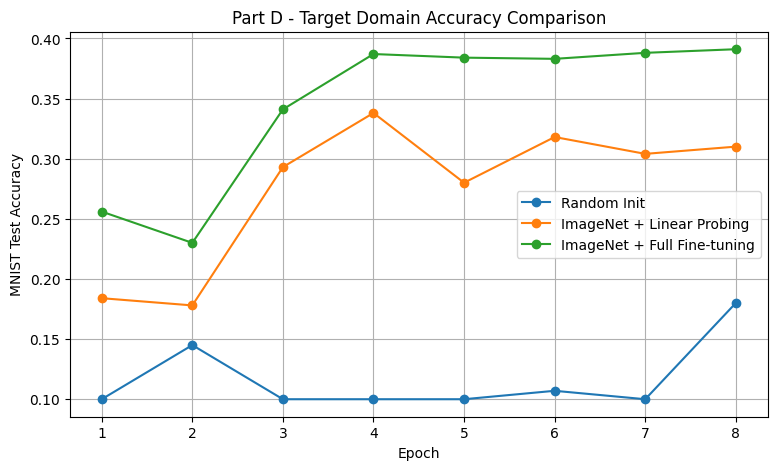

Saved: /content/q1_part_d_outputs/part_d_mnist_accuracy_comparison.png


In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    random_history_df["epoch"],
    random_history_df["mnist_test_acc"],
    marker="o",
    label="Random Init"
)

plt.plot(
    linear_history_df["epoch"],
    linear_history_df["mnist_test_acc"],
    marker="o",
    label="ImageNet + Linear Probing"
)

plt.plot(
    finetune_history_df["epoch"],
    finetune_history_df["mnist_test_acc"],
    marker="o",
    label="ImageNet + Full Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("MNIST Test Accuracy")
plt.title("Part D - Target Domain Accuracy Comparison")
plt.legend()
plt.grid(True)

mnist_acc_path = os.path.join(OUTPUT_DIR, "part_d_mnist_accuracy_comparison.png")
plt.savefig(mnist_acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", mnist_acc_path)

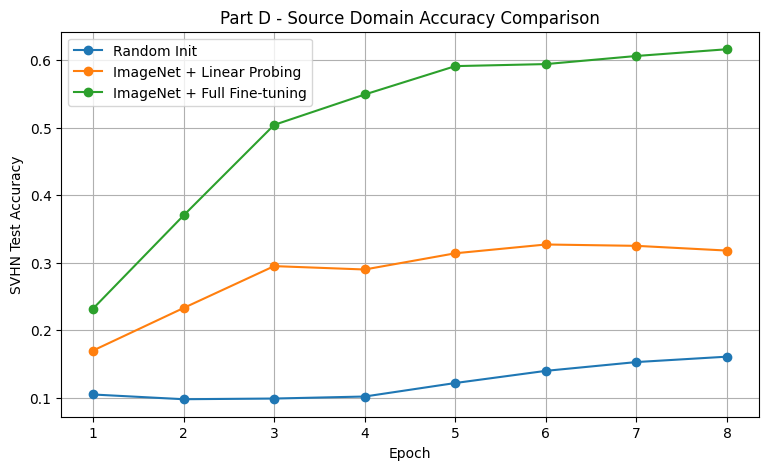

Saved: /content/q1_part_d_outputs/part_d_svhn_accuracy_comparison.png


In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    random_history_df["epoch"],
    random_history_df["svhn_test_acc"],
    marker="o",
    label="Random Init"
)

plt.plot(
    linear_history_df["epoch"],
    linear_history_df["svhn_test_acc"],
    marker="o",
    label="ImageNet + Linear Probing"
)

plt.plot(
    finetune_history_df["epoch"],
    finetune_history_df["svhn_test_acc"],
    marker="o",
    label="ImageNet + Full Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("SVHN Test Accuracy")
plt.title("Part D - Source Domain Accuracy Comparison")
plt.legend()
plt.grid(True)

svhn_acc_path = os.path.join(OUTPUT_DIR, "part_d_svhn_accuracy_comparison.png")
plt.savefig(svhn_acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", svhn_acc_path)

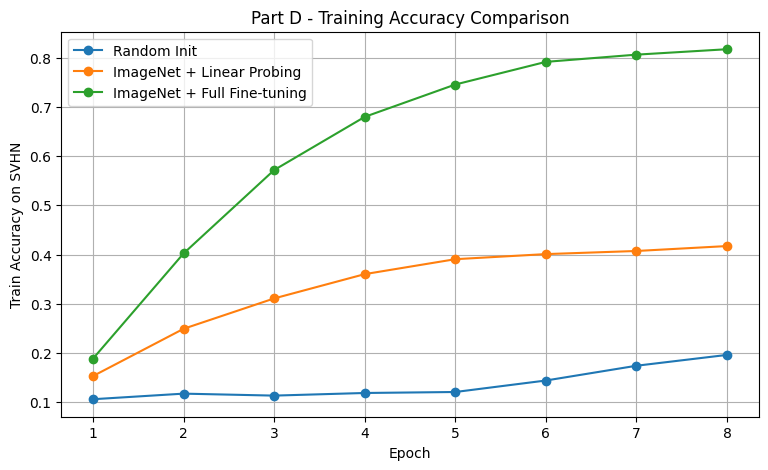

Saved: /content/q1_part_d_outputs/part_d_train_accuracy_comparison.png


In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    random_history_df["epoch"],
    random_history_df["train_acc"],
    marker="o",
    label="Random Init"
)

plt.plot(
    linear_history_df["epoch"],
    linear_history_df["train_acc"],
    marker="o",
    label="ImageNet + Linear Probing"
)

plt.plot(
    finetune_history_df["epoch"],
    finetune_history_df["train_acc"],
    marker="o",
    label="ImageNet + Full Fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy on SVHN")
plt.title("Part D - Training Accuracy Comparison")
plt.legend()
plt.grid(True)

train_acc_path = os.path.join(OUTPUT_DIR, "part_d_train_accuracy_comparison.png")
plt.savefig(train_acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", train_acc_path)

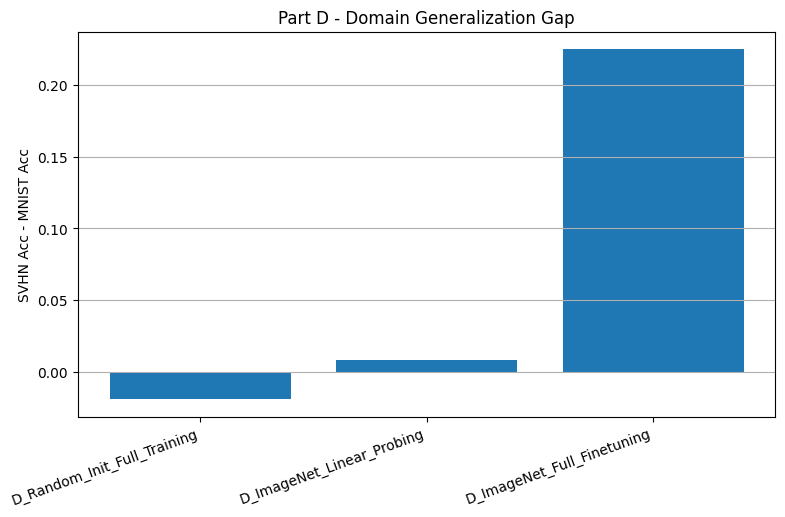

Saved: /content/q1_part_d_outputs/part_d_domain_gap_comparison.png


,experiment,domain_gap_svhn_minus_mnist
0,D_Random_Init_Full_Training,-0.019
1,D_ImageNet_Linear_Probing,0.008
2,D_ImageNet_Full_Finetuning,0.225


In [ ]:
gap_df_d = part_d_summary_df[[
    "experiment",
    "domain_gap_svhn_minus_mnist"
]].copy()

plt.figure(figsize=(9, 5))

plt.bar(
    gap_df_d["experiment"],
    gap_df_d["domain_gap_svhn_minus_mnist"]
)

plt.ylabel("SVHN Acc - MNIST Acc")
plt.title("Part D - Domain Generalization Gap")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")

gap_path = os.path.join(OUTPUT_DIR, "part_d_domain_gap_comparison.png")
plt.savefig(gap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", gap_path)
gap_df_d

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمودارهای بخش د</h3>

<p>
نمودار دقت MNIST نشان می‌دهد که Full Fine-tuning تقریباً در تمام epochها بالاتر از دو روش دیگر قرار دارد. این نتیجه نشان می‌دهد که در شرایط تغییر دامنه، صرفاً استفاده از ویژگی‌های ثابت ImageNet کافی نیست و لازم است feature extractor نیز با مسئله تشخیص ارقام سازگار شود.
</p>

<p>
در نمودار دقت SVHN نیز Full Fine-tuning بهترین روند رشد را دارد و نسبت به Linear Probing و Random Init عملکرد بالاتری نشان می‌دهد. نمودار دقت آموزش نیز همین نتیجه را تأیید می‌کند؛ مدل دارای وزن‌های ImageNet و آموزش کامل، سریع‌تر و بهتر یاد می‌گیرد.
</p>

<p>
در نمودار Domain Gap ممکن است مقدار gap برای Random Init کوچک‌تر به نظر برسد، اما این موضوع نباید به عنوان تعمیم بهتر تفسیر شود؛ زیرا دقت این مدل روی هر دو دامنه پایین است. بنابراین gap فقط زمانی معیار معناداری است که همراه با accuracy تحلیل شود. از نظر عملکرد واقعی، Full Fine-tuning بهترین روش این بخش است.
</p>

</div>

In [ ]:
best_svhn = part_d_summary_df.loc[
    part_d_summary_df["final_svhn_test_acc"].idxmax()
]

best_mnist = part_d_summary_df.loc[
    part_d_summary_df["final_mnist_test_acc"].idxmax()
]

smallest_gap = part_d_summary_df.loc[
    part_d_summary_df["domain_gap_svhn_minus_mnist"].idxmin()
]

print("Best SVHN accuracy:")
print(best_svhn[["experiment", "final_svhn_test_acc"]])
print()

print("Best MNIST accuracy:")
print(best_mnist[["experiment", "final_mnist_test_acc"]])
print()

print("Smallest domain gap:")
print(smallest_gap[["experiment", "domain_gap_svhn_minus_mnist"]])
print()

print("Interpretation guide:")
print("- Best MNIST accuracy is the most important indicator for target-domain generalization.")
print("- Smallest domain gap indicates more consistent behavior across SVHN and MNIST.")
print("- If full fine-tuning performs better than linear probing, it suggests that adapting the feature extractor is useful under domain shift.")

Best SVHN accuracy:
experiment             D_ImageNet_Full_Finetuning
final_svhn_test_acc                         0.616
Name: 2, dtype: object

Best MNIST accuracy:
experiment              D_ImageNet_Full_Finetuning
final_mnist_test_acc                         0.391
Name: 2, dtype: object

Smallest domain gap:
experiment                     D_Random_Init_Full_Training
domain_gap_svhn_minus_mnist                         -0.019
Name: 0, dtype: object

Interpretation guide:
- Best MNIST accuracy is the most important indicator for target-domain generalization.
- Smallest domain gap indicates more consistent behavior across SVHN and MNIST.
- If full fine-tuning performs better than linear probing, it suggests that adapting the feature extractor is useful under domain shift.


In [ ]:
import os
import time
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm


SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


DATA_ROOT = "/content/data"
OUTPUT_DIR = "/content/q1_part_e_outputs"

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_WORKERS = 0
BATCH_SIZE = 128

USE_SUBSET_E = True

MNIST_TRAIN_SUBSET_E = 5000
MNIST_TEST_SUBSET_E = 1000
SVHN_TEST_SUBSET_E = 1000
SVHN_ADAPT_SUBSET_E = 500

SOURCE_EPOCHS = 10
ADAPT_EPOCHS = 8

SOURCE_LR = 1e-3
ADAPT_LR = 1e-4

WEIGHT_DECAY = 5e-4

print("OUTPUT_DIR:", OUTPUT_DIR)
print("USE_SUBSET_E:", USE_SUBSET_E)
print("SOURCE_EPOCHS:", SOURCE_EPOCHS)
print("ADAPT_EPOCHS:", ADAPT_EPOCHS)

Device: cpu
OUTPUT_DIR: /content/q1_part_e_outputs
USE_SUBSET_E: True
SOURCE_EPOCHS: 10
ADAPT_EPOCHS: 8


In [ ]:
import os
import time
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm


SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


DATA_ROOT = "/content/data"
OUTPUT_DIR = "/content/q1_part_e_outputs"

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


NUM_WORKERS = 0
BATCH_SIZE = 128

USE_SUBSET_E = True

MNIST_TRAIN_SUBSET_E = 5000
MNIST_TEST_SUBSET_E = 1000
SVHN_TEST_SUBSET_E = 1000
SVHN_ADAPT_SUBSET_E = 500

SOURCE_EPOCHS = 10
ADAPT_EPOCHS = 8

SOURCE_LR = 1e-3
ADAPT_LR = 1e-4

WEIGHT_DECAY = 5e-4

print("OUTPUT_DIR:", OUTPUT_DIR)
print("USE_SUBSET_E:", USE_SUBSET_E)
print("SOURCE_EPOCHS:", SOURCE_EPOCHS)
print("ADAPT_EPOCHS:", ADAPT_EPOCHS)

Device: cpu
OUTPUT_DIR: /content/q1_part_e_outputs
USE_SUBSET_E: True
SOURCE_EPOCHS: 10
ADAPT_EPOCHS: 8


In [ ]:
mnist_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5))
])

svhn_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5))
])


def get_dataset_labels(dataset):
    """
    Extract labels from torchvision datasets.
    MNIST uses .targets
    SVHN uses .labels
    """
    if hasattr(dataset, "labels"):
        labels = dataset.labels
    elif hasattr(dataset, "targets"):
        labels = dataset.targets
    else:
        raise ValueError("Dataset has no labels or targets attribute.")

    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()
    else:
        labels = np.array(labels)

    return labels.astype(int)


def make_balanced_subset(dataset, n_samples, n_classes=10, seed=42):
    """
    Creates a class-balanced subset.
    Example: n_samples=500 gives about 50 samples per class.
    """
    labels = get_dataset_labels(dataset)
    rng = np.random.default_rng(seed)

    indices = []
    per_class = n_samples // n_classes
    remainder = n_samples % n_classes

    for cls in range(n_classes):
        cls_indices = np.where(labels == cls)[0]
        n_take = per_class + (1 if cls < remainder else 0)
        n_take = min(n_take, len(cls_indices))

        selected = rng.choice(cls_indices, size=n_take, replace=False)
        indices.extend(selected.tolist())

    rng.shuffle(indices)
    return Subset(dataset, indices)



mnist_train_full = datasets.MNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=mnist_transform
)

mnist_test_full = datasets.MNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=mnist_transform
)

svhn_train_full = datasets.SVHN(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=svhn_transform
)

svhn_test_full = datasets.SVHN(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=svhn_transform
)


if USE_SUBSET_E:
    mnist_train = make_balanced_subset(
        mnist_train_full,
        MNIST_TRAIN_SUBSET_E,
        seed=SEED
    )

    mnist_test = make_balanced_subset(
        mnist_test_full,
        MNIST_TEST_SUBSET_E,
        seed=SEED
    )

    svhn_test = make_balanced_subset(
        svhn_test_full,
        SVHN_TEST_SUBSET_E,
        seed=SEED
    )

    svhn_adapt = make_balanced_subset(
        svhn_train_full,
        SVHN_ADAPT_SUBSET_E,
        seed=SEED
    )

    print("Using balanced subsets for Part E.")
else:
    mnist_train = mnist_train_full
    mnist_test = mnist_test_full
    svhn_test = svhn_test_full
    svhn_adapt = make_balanced_subset(
        svhn_train_full,
        SVHN_ADAPT_SUBSET_E,
        seed=SEED
    )

pin_memory = True if torch.cuda.is_available() else False

mnist_train_loader = DataLoader(
    mnist_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

mnist_test_loader = DataLoader(
    mnist_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

svhn_test_loader = DataLoader(
    svhn_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

svhn_adapt_loader = DataLoader(
    svhn_adapt,
    batch_size=64,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("MNIST train size:", len(mnist_train))
print("MNIST test size:", len(mnist_test))
print("SVHN test size:", len(svhn_test))
print("SVHN adaptation size:", len(svhn_adapt))

x_mnist, y_mnist = next(iter(mnist_train_loader))
x_svhn, y_svhn = next(iter(svhn_adapt_loader))

print("MNIST batch shape:", x_mnist.shape)
print("SVHN adapt batch shape:", x_svhn.shape)

Using balanced subsets for Part E.
MNIST train size: 5000
MNIST test size: 1000
SVHN test size: 1000
SVHN adaptation size: 500
MNIST batch shape: torch.Size([128, 3, 32, 32])
SVHN adapt batch shape: torch.Size([64, 3, 32, 32])


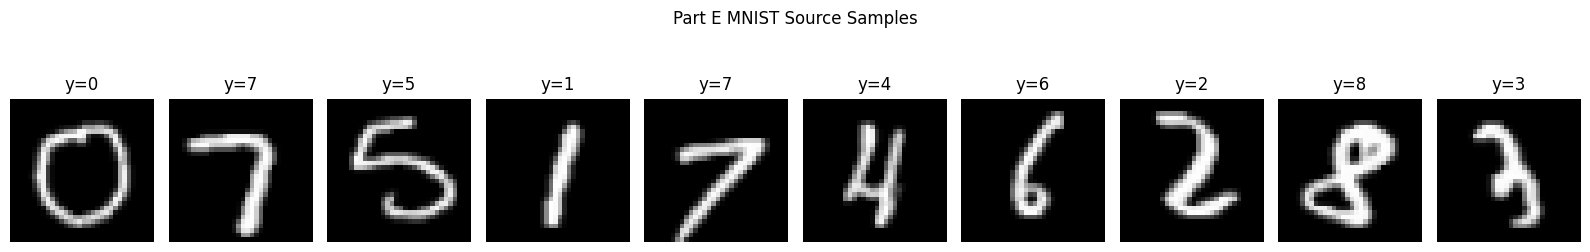

Saved: /content/q1_part_e_outputs/part_e_mnist_source_samples.png


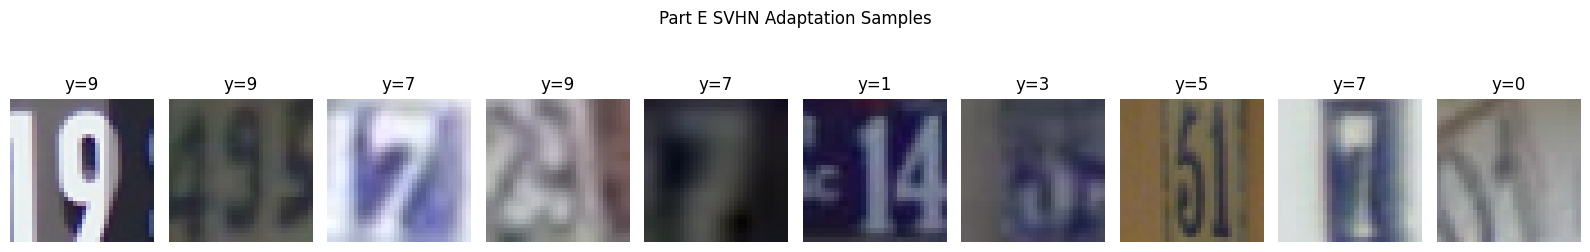

Saved: /content/q1_part_e_outputs/part_e_svhn_adaptation_samples.png


In [ ]:


def unnormalize(img):
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)


def show_batch(loader, title, n=10):
    images, labels = next(iter(loader))

    images = images[:n]
    labels = labels[:n]

    plt.figure(figsize=(16, 3))

    for i in range(n):
        img = unnormalize(images[i]).permute(1, 2, 0).cpu().numpy()
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f"y={labels[i].item()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()

    fig_path = os.path.join(OUTPUT_DIR, title.replace(" ", "_").lower() + ".png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)


show_batch(mnist_train_loader, "Part E MNIST Source Samples", n=10)
show_batch(svhn_adapt_loader, "Part E SVHN Adaptation Samples", n=10)

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, use_bn=True):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(planes) if use_bn else nn.Identity()

        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(planes) if use_bn else nn.Identity()

        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes * self.expansion) if use_bn else nn.Identity()
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


class ResNet18Small(nn.Module):
    """
    Manual ResNet18 adapted for 32x32 digit images.
    Configuration: [2, 2, 2, 2]
    """

    def __init__(self, num_classes=10, use_bn=True):
        super().__init__()

        self.in_planes = 64
        self.use_bn = use_bn

        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64) if use_bn else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)

        layers = []

        for s in strides:
            layers.append(
                BasicBlock(
                    in_planes=self.in_planes,
                    planes=planes,
                    stride=s,
                    use_bn=self.use_bn
                )
            )
            self.in_planes = planes * BasicBlock.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out


test_model = ResNet18Small(num_classes=10, use_bn=True).to(device)
dummy = torch.randn(2, 3, 32, 32).to(device)
out = test_model(dummy)

print("Output shape:", out.shape)

del test_model
torch.cuda.empty_cache()

Output shape: torch.Size([2, 10])


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        progress_bar.set_postfix({
            "loss": running_loss / total,
            "acc": correct / total
        })

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    return running_loss / total, correct / total


print("Train/evaluate functions are ready.")

Train/evaluate functions are ready.


In [ ]:
set_seed(SEED)

source_model = ResNet18Small(num_classes=10, use_bn=True).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    source_model.parameters(),
    lr=SOURCE_LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=SOURCE_EPOCHS
)

source_history = []

print("=" * 80)
print("Stage 1: Training source model on MNIST")
print("=" * 80)

start_time = time.time()

for epoch in range(1, SOURCE_EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(
        model=source_model,
        loader=mnist_train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    mnist_test_loss, mnist_test_acc = evaluate(
        model=source_model,
        loader=mnist_test_loader,
        criterion=criterion,
        device=device
    )

    svhn_test_loss, svhn_test_acc = evaluate(
        model=source_model,
        loader=svhn_test_loader,
        criterion=criterion,
        device=device
    )

    scheduler.step()

    row = {
        "stage": "source_training",
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "mnist_test_loss": mnist_test_loss,
        "mnist_test_acc": mnist_test_acc,
        "svhn_test_loss": svhn_test_loss,
        "svhn_test_acc": svhn_test_acc,
        "lr": optimizer.param_groups[0]["lr"],
        "epoch_time_sec": time.time() - epoch_start
    }

    source_history.append(row)

    print(
        f"Epoch [{epoch:02d}/{SOURCE_EPOCHS}] | "
        f"Train Acc: {train_acc:.4f} | "
        f"MNIST Acc: {mnist_test_acc:.4f} | "
        f"SVHN Acc: {svhn_test_acc:.4f} | "
        f"Time: {row['epoch_time_sec']:.1f}s"
    )

print(f"Total source training time: {(time.time() - start_time) / 60:.2f} minutes")

source_history_df = pd.DataFrame(source_history)
source_history_path = os.path.join(OUTPUT_DIR, "part_e_source_training_history.csv")
source_history_df.to_csv(source_history_path, index=False)

print("Saved:", source_history_path)
source_history_df

Stage 1: Training source model on MNIST


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [01/10] | Train Acc: 0.8590 | MNIST Acc: 0.9120 | SVHN Acc: 0.1080 | Time: 408.2s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [02/10] | Train Acc: 0.9612 | MNIST Acc: 0.8880 | SVHN Acc: 0.1330 | Time: 408.7s


...

Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [09/10] | Train Acc: 0.9992 | MNIST Acc: 0.9850 | SVHN Acc: 0.1060 | Time: 407.4s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [10/10] | Train Acc: 0.9996 | MNIST Acc: 0.9850 | SVHN Acc: 0.1040 | Time: 405.9s
Total source training time: 67.90 minutes
Saved: /content/q1_part_e_outputs/part_e_source_training_history.csv


,stage,epoch,train_loss,train_acc,mnist_test_loss,mnist_test_acc,svhn_test_loss,svhn_test_acc,lr,epoch_time_sec
0,source_training,1,0.463459,0.8590,0.284902,0.912,8.952071,0.108,0.000976,408.214548
1,source_training,2,0.119037,0.9612,0.376013,0.888,7.244424,0.133,0.000905,408.682822
2,source_training,3,0.068945,0.9794,0.103952,0.968,7.232227,0.145,0.000794,408.537262
3,source_training,4,0.027473,0.9928,0.065298,0.976,9.954955,0.121,0.000655,408.500690
4,source_training,5,0.014147,0.9964,0.075118,0.976,12.213391,0.121,0.000500,407.419944
5,source_training,6,0.062118,0.9812,0.070992,0.978,13.649291,0.104,0.000345,406.123116
6,source_training,7,0.037217,0.9878,0.054004,0.981,18.931681,0.104,0.000206,407.286665
7,source_training,8,0.009237,0.9986,0.047962,0.984,18.314791,0.105,0.000095,406.217031
8,source_training,9,0.005060,0.9992,0.046801,0.985,18.636739,0.106,0.000024,407.367224
9,source_training,10,0.004212,0.9996,0.047594,0.985,18.457079,0.104,0.000000,405.864370


In [ ]:
source_model_path = os.path.join(OUTPUT_DIR, "part_e_source_only_mnist_model.pth")

torch.save({
    "model_state_dict": source_model.state_dict(),
    "source_history": source_history,
    "config": {
        "source_domain": "MNIST",
        "target_domain": "SVHN",
        "source_epochs": SOURCE_EPOCHS,
        "source_lr": SOURCE_LR,
        "train_subset": MNIST_TRAIN_SUBSET_E if USE_SUBSET_E else "full",
        "svhn_test_subset": SVHN_TEST_SUBSET_E if USE_SUBSET_E else "full"
    }
}, source_model_path)

print("Saved source-only model:", source_model_path)

source_only_state = copy.deepcopy(source_model.state_dict())

Saved source-only model: /content/q1_part_e_outputs/part_e_source_only_mnist_model.pth


In [ ]:
adapted_model = ResNet18Small(num_classes=10, use_bn=True).to(device)
adapted_model.load_state_dict(source_only_state)

adapt_criterion = nn.CrossEntropyLoss()

adapt_optimizer = optim.AdamW(
    adapted_model.parameters(),
    lr=ADAPT_LR,
    weight_decay=WEIGHT_DECAY
)

adapt_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    adapt_optimizer,
    T_max=ADAPT_EPOCHS
)

adapt_history = []

print("=" * 80)
print("Stage 2: Fine-tuning on 500 labeled SVHN samples")
print("=" * 80)

start_time = time.time()

before_mnist_loss, before_mnist_acc = evaluate(
    adapted_model,
    mnist_test_loader,
    adapt_criterion,
    device
)

before_svhn_loss, before_svhn_acc = evaluate(
    adapted_model,
    svhn_test_loader,
    adapt_criterion,
    device
)

adapt_history.append({
    "stage": "before_adaptation",
    "epoch": 0,
    "adapt_train_loss": None,
    "adapt_train_acc": None,
    "mnist_test_loss": before_mnist_loss,
    "mnist_test_acc": before_mnist_acc,
    "svhn_test_loss": before_svhn_loss,
    "svhn_test_acc": before_svhn_acc,
    "lr": ADAPT_LR,
    "epoch_time_sec": 0
})

print(
    f"Before adaptation | "
    f"MNIST Acc: {before_mnist_acc:.4f} | "
    f"SVHN Acc: {before_svhn_acc:.4f}"
)

for epoch in range(1, ADAPT_EPOCHS + 1):
    epoch_start = time.time()

    adapt_train_loss, adapt_train_acc = train_one_epoch(
        model=adapted_model,
        loader=svhn_adapt_loader,
        criterion=adapt_criterion,
        optimizer=adapt_optimizer,
        device=device
    )

    mnist_test_loss, mnist_test_acc = evaluate(
        model=adapted_model,
        loader=mnist_test_loader,
        criterion=adapt_criterion,
        device=device
    )

    svhn_test_loss, svhn_test_acc = evaluate(
        model=adapted_model,
        loader=svhn_test_loader,
        criterion=adapt_criterion,
        device=device
    )

    adapt_scheduler.step()

    row = {
        "stage": "adaptation",
        "epoch": epoch,
        "adapt_train_loss": adapt_train_loss,
        "adapt_train_acc": adapt_train_acc,
        "mnist_test_loss": mnist_test_loss,
        "mnist_test_acc": mnist_test_acc,
        "svhn_test_loss": svhn_test_loss,
        "svhn_test_acc": svhn_test_acc,
        "lr": adapt_optimizer.param_groups[0]["lr"],
        "epoch_time_sec": time.time() - epoch_start
    }

    adapt_history.append(row)

    print(
        f"Adapt Epoch [{epoch:02d}/{ADAPT_EPOCHS}] | "
        f"Adapt Train Acc: {adapt_train_acc:.4f} | "
        f"MNIST Acc: {mnist_test_acc:.4f} | "
        f"SVHN Acc: {svhn_test_acc:.4f} | "
        f"Time: {row['epoch_time_sec']:.1f}s"
    )

print(f"Total adaptation time: {(time.time() - start_time) / 60:.2f} minutes")

adapt_history_df = pd.DataFrame(adapt_history)
adapt_history_path = os.path.join(OUTPUT_DIR, "part_e_adaptation_history.csv")
adapt_history_df.to_csv(adapt_history_path, index=False)

print("Saved:", adapt_history_path)
adapt_history_df

Stage 2: Fine-tuning on 500 labeled SVHN samples
Before adaptation | MNIST Acc: 0.9850 | SVHN Acc: 0.1040


Training:   0%|          | 0/8 [00:00<?, ?it/s]

Adapt Epoch [01/8] | Adapt Train Acc: 0.2280 | MNIST Acc: 0.8740 | SVHN Acc: 0.2820 | Time: 78.2s


Training:   0%|          | 0/8 [00:00<?, ?it/s]

Adapt Epoch [02/8] | Adapt Train Acc: 0.3500 | MNIST Acc: 0.8100 | SVHN Acc: 0.3420 | Time: 77.9s


...

Training:   0%|          | 0/8 [00:00<?, ?it/s]

Adapt Epoch [07/8] | Adapt Train Acc: 0.6620 | MNIST Acc: 0.8310 | SVHN Acc: 0.4070 | Time: 78.0s


Training:   0%|          | 0/8 [00:00<?, ?it/s]

Adapt Epoch [08/8] | Adapt Train Acc: 0.6640 | MNIST Acc: 0.8220 | SVHN Acc: 0.4030 | Time: 77.2s
Total adaptation time: 11.08 minutes
Saved: /content/q1_part_e_outputs/part_e_adaptation_history.csv


,stage,epoch,adapt_train_loss,adapt_train_acc,mnist_test_loss,mnist_test_acc,svhn_test_loss,svhn_test_acc,lr,epoch_time_sec
0,before_adaptation,0,NaN,NaN,0.047594,0.985,18.457079,0.104,0.000100,0.000000
1,adaptation,1,4.751899,0.228,0.478361,0.874,3.389681,0.282,0.000096,78.190340
2,adaptation,2,2.904191,0.350,0.871182,0.810,2.724829,0.342,0.000085,77.935778
3,adaptation,3,1.982751,0.456,0.443647,0.889,2.355734,0.374,0.000069,77.448659
4,adaptation,4,1.521582,0.488,0.889163,0.820,2.223154,0.375,0.000050,77.805469
5,adaptation,5,1.268610,0.580,0.891561,0.819,2.070422,0.385,0.000031,77.452344
6,adaptation,6,1.120891,0.616,0.736160,0.836,1.978653,0.400,0.000015,77.367864
7,adaptation,7,1.037600,0.662,0.805085,0.831,1.968635,0.407,0.000004,78.044571
8,adaptation,8,1.031620,0.664,0.861734,0.822,1.974789,0.403,0.000000,77.235657


In [ ]:
before_row = adapt_history_df[adapt_history_df["epoch"] == 0].iloc[0]
after_row = adapt_history_df.iloc[-1]

part_e_summary_df = pd.DataFrame([
    {
        "model_stage": "Source-only MNIST model",
        "train_data": "MNIST",
        "adaptation_data": "0 SVHN samples",
        "mnist_test_acc": before_row["mnist_test_acc"],
        "svhn_test_acc": before_row["svhn_test_acc"],
        "mnist_test_loss": before_row["mnist_test_loss"],
        "svhn_test_loss": before_row["svhn_test_loss"],
        "domain_gap_mnist_minus_svhn": before_row["mnist_test_acc"] - before_row["svhn_test_acc"]
    },
    {
        "model_stage": "Adapted model",
        "train_data": "MNIST + SVHN",
        "adaptation_data": f"{SVHN_ADAPT_SUBSET_E} labeled SVHN samples",
        "mnist_test_acc": after_row["mnist_test_acc"],
        "svhn_test_acc": after_row["svhn_test_acc"],
        "mnist_test_loss": after_row["mnist_test_loss"],
        "svhn_test_loss": after_row["svhn_test_loss"],
        "domain_gap_mnist_minus_svhn": after_row["mnist_test_acc"] - after_row["svhn_test_acc"]
    }
])

summary_path = os.path.join(OUTPUT_DIR, "part_e_final_summary.csv")
part_e_summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
part_e_summary_df

Saved: /content/q1_part_e_outputs/part_e_final_summary.csv


,model_stage,train_data,adaptation_data,mnist_test_acc,svhn_test_acc,mnist_test_loss,svhn_test_loss,domain_gap_mnist_minus_svhn
0,Source-only MNIST model,MNIST,0 SVHN samples,0.985,0.104,0.047594,18.457079,0.881
1,Adapted model,MNIST + SVHN,500 labeled SVHN samples,0.822,0.403,0.861734,1.974789,0.419


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل عددی بخش هـ: انطباق دامنه</h3>

<p>
در این بخش مدل ابتدا فقط روی MNIST آموزش داده شد و سپس روی SVHN ارزیابی گردید. مدل source-only روی MNIST دقت بسیار بالای 0.985 به دست آورد، اما روی SVHN فقط به دقت 0.104 رسید. این افت شدید نشان می‌دهد که مدل ویژگی‌هایی را یاد گرفته که برای تصاویر ساده MNIST مناسب هستند، اما در برابر تصاویر واقعی، رنگی و دارای پس‌زمینه SVHN پایدار نیستند.
</p>

<p>
پس از fine-tuning با ۵۰۰ نمونه برچسب‌دار SVHN، دقت روی SVHN از 0.104 به 0.403 افزایش یافت و Loss دامنه هدف نیز به شکل قابل توجهی کاهش پیدا کرد. بنابراین حتی تعداد کمی نمونه از دامنه هدف می‌تواند به سازگاری مدل کمک کند. با این حال، دقت MNIST از 0.985 به 0.822 کاهش یافت که نشانه‌ای از catastrophic forgetting است.
</p>

</div>

In [ ]:
svhn_improvement = after_row["svhn_test_acc"] - before_row["svhn_test_acc"]
mnist_change = after_row["mnist_test_acc"] - before_row["mnist_test_acc"]

gap_before = before_row["mnist_test_acc"] - before_row["svhn_test_acc"]
gap_after = after_row["mnist_test_acc"] - after_row["svhn_test_acc"]
gap_change = gap_after - gap_before

print("SVHN accuracy before adaptation:", round(before_row["svhn_test_acc"], 4))
print("SVHN accuracy after adaptation:", round(after_row["svhn_test_acc"], 4))
print("SVHN accuracy improvement:", round(svhn_improvement, 4))
print()

print("MNIST accuracy before adaptation:", round(before_row["mnist_test_acc"], 4))
print("MNIST accuracy after adaptation:", round(after_row["mnist_test_acc"], 4))
print("MNIST accuracy change:", round(mnist_change, 4))
print()

print("Domain gap before adaptation:", round(gap_before, 4))
print("Domain gap after adaptation:", round(gap_after, 4))
print("Domain gap change:", round(gap_change, 4))
print()

if svhn_improvement > 0:
    print("Result: Adaptation improved target-domain SVHN accuracy.")
else:
    print("Result: Adaptation did not improve target-domain SVHN accuracy.")

if mnist_change < 0:
    print("Observation: MNIST accuracy decreased after adaptation, which may indicate catastrophic forgetting.")
else:
    print("Observation: MNIST accuracy did not decrease after adaptation.")

SVHN accuracy before adaptation: 0.104
SVHN accuracy after adaptation: 0.403
SVHN accuracy improvement: 0.299

MNIST accuracy before adaptation: 0.985
MNIST accuracy after adaptation: 0.822
MNIST accuracy change: -0.163

Domain gap before adaptation: 0.881
Domain gap after adaptation: 0.419
Domain gap change: -0.462

Result: Adaptation improved target-domain SVHN accuracy.
Observation: MNIST accuracy decreased after adaptation, which may indicate catastrophic forgetting.


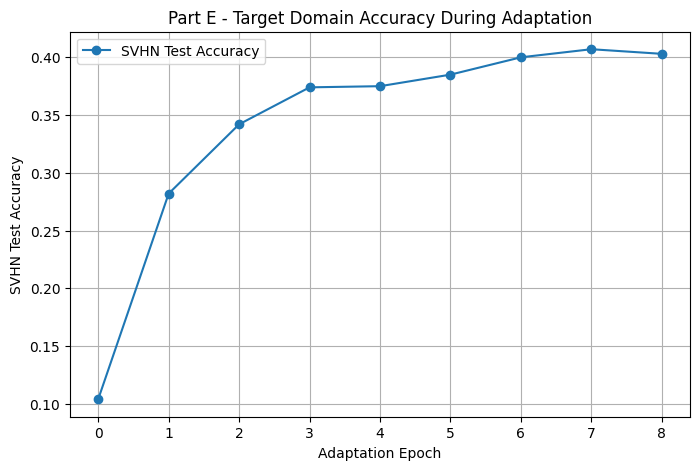

Saved: /content/q1_part_e_outputs/part_e_svhn_accuracy_during_adaptation.png


In [ ]:

plt.figure(figsize=(8, 5))

plt.plot(
    adapt_history_df["epoch"],
    adapt_history_df["svhn_test_acc"],
    marker="o",
    label="SVHN Test Accuracy"
)

plt.xlabel("Adaptation Epoch")
plt.ylabel("SVHN Test Accuracy")
plt.title("Part E - Target Domain Accuracy During Adaptation")
plt.legend()
plt.grid(True)

svhn_acc_path = os.path.join(OUTPUT_DIR, "part_e_svhn_accuracy_during_adaptation.png")
plt.savefig(svhn_acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", svhn_acc_path)

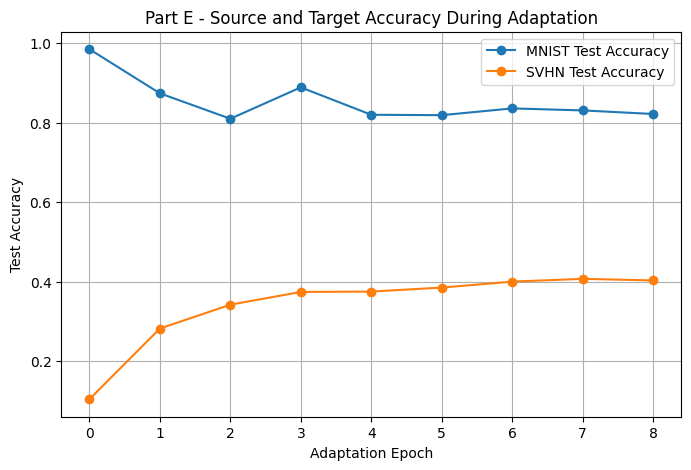

Saved: /content/q1_part_e_outputs/part_e_mnist_svhn_accuracy_during_adaptation.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    adapt_history_df["epoch"],
    adapt_history_df["mnist_test_acc"],
    marker="o",
    label="MNIST Test Accuracy"
)

plt.plot(
    adapt_history_df["epoch"],
    adapt_history_df["svhn_test_acc"],
    marker="o",
    label="SVHN Test Accuracy"
)

plt.xlabel("Adaptation Epoch")
plt.ylabel("Test Accuracy")
plt.title("Part E - Source and Target Accuracy During Adaptation")
plt.legend()
plt.grid(True)

both_acc_path = os.path.join(OUTPUT_DIR, "part_e_mnist_svhn_accuracy_during_adaptation.png")
plt.savefig(both_acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", both_acc_path)

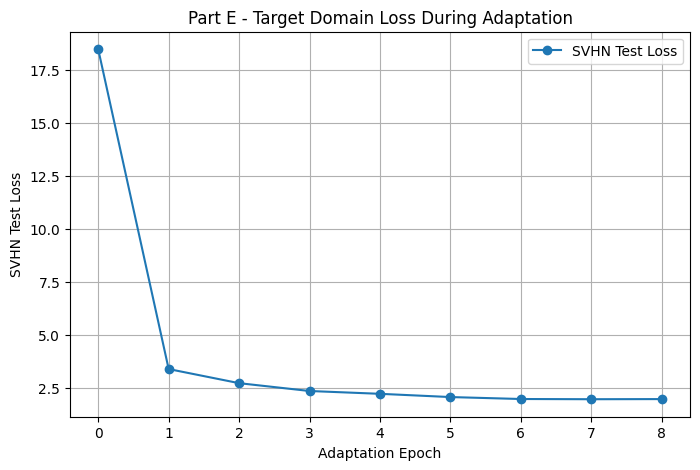

Saved: /content/q1_part_e_outputs/part_e_svhn_loss_during_adaptation.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    adapt_history_df["epoch"],
    adapt_history_df["svhn_test_loss"],
    marker="o",
    label="SVHN Test Loss"
)

plt.xlabel("Adaptation Epoch")
plt.ylabel("SVHN Test Loss")
plt.title("Part E - Target Domain Loss During Adaptation")
plt.legend()
plt.grid(True)

svhn_loss_path = os.path.join(OUTPUT_DIR, "part_e_svhn_loss_during_adaptation.png")
plt.savefig(svhn_loss_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", svhn_loss_path)

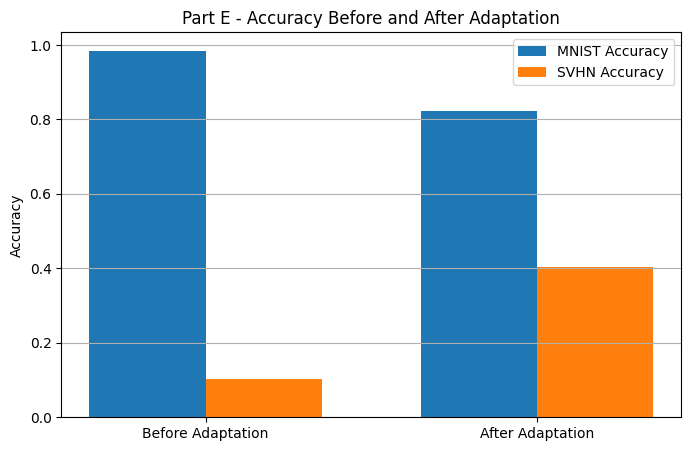

Saved: /content/q1_part_e_outputs/part_e_before_after_adaptation.png


,stage,MNIST Accuracy,SVHN Accuracy
0,Before Adaptation,0.985,0.104
1,After Adaptation,0.822,0.403


In [ ]:
before_after_df = pd.DataFrame({
    "stage": ["Before Adaptation", "After Adaptation"],
    "MNIST Accuracy": [
        before_row["mnist_test_acc"],
        after_row["mnist_test_acc"]
    ],
    "SVHN Accuracy": [
        before_row["svhn_test_acc"],
        after_row["svhn_test_acc"]
    ]
})

x = np.arange(len(before_after_df["stage"]))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    before_after_df["MNIST Accuracy"],
    width,
    label="MNIST Accuracy"
)

plt.bar(
    x + width / 2,
    before_after_df["SVHN Accuracy"],
    width,
    label="SVHN Accuracy"
)

plt.xticks(x, before_after_df["stage"])
plt.ylabel("Accuracy")
plt.title("Part E - Accuracy Before and After Adaptation")
plt.legend()
plt.grid(axis="y")

before_after_path = os.path.join(OUTPUT_DIR, "part_e_before_after_adaptation.png")
plt.savefig(before_after_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", before_after_path)
before_after_df

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمودارهای بخش هـ</h3>

<p>
نمودار دقت SVHN در طول adaptation نشان می‌دهد که بیشترین جهش عملکرد در epochهای ابتدایی رخ داده است. این یعنی مدل پس از مشاهده تعداد محدودی نمونه از دامنه هدف، به سرعت بخشی از ویژگی‌های لازم برای SVHN را یاد گرفته است. سپس روند رشد آهسته‌تر شده و دقت به حدود 0.403 رسیده است.
</p>

<p>
نمودار مقایسه دقت MNIST و SVHN نشان‌دهنده یک trade-off روشن است. با افزایش دقت SVHN، دقت MNIST کاهش یافته است. این یعنی fine-tuning روی دامنه هدف مدل را به سمت توزیع SVHN حرکت داده، اما بخشی از سازگاری قبلی با MNIST از دست رفته است. نمودار قبل و بعد از adaptation نیز همین نتیجه را تأیید می‌کند: بهبود دامنه هدف در برابر افت نسبی دامنه منبع.
</p>

</div>

In [ ]:
# Save adapted model

adapted_model_path = os.path.join(OUTPUT_DIR, "part_e_adapted_model_mnist_to_svhn.pth")

torch.save({
    "model_state_dict": adapted_model.state_dict(),
    "source_history": source_history,
    "adapt_history": adapt_history,
    "summary": part_e_summary_df.to_dict(orient="records"),
    "config": {
        "source_domain": "MNIST",
        "target_domain": "SVHN",
        "source_epochs": SOURCE_EPOCHS,
        "adapt_epochs": ADAPT_EPOCHS,
        "source_lr": SOURCE_LR,
        "adapt_lr": ADAPT_LR,
        "svhn_adaptation_samples": SVHN_ADAPT_SUBSET_E,
        "batch_size": BATCH_SIZE,
        "image_size": "32x32",
        "model": "Manual ResNet18Small"
    }
}, adapted_model_path)

print("Saved adapted model:", adapted_model_path)

Saved adapted model: /content/q1_part_e_outputs/part_e_adapted_model_mnist_to_svhn.pth


In [ ]:
!pip install -q umap-learn

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

import umap
from sklearn.metrics import silhouette_score


SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


DATA_ROOT = "/content/data"
OUTPUT_DIR = "/content/q1_part_f_outputs"

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


NUM_WORKERS = 0
BATCH_SIZE = 128

USE_SUBSET_F = True

SVHN_TRAIN_SUBSET_F = 5000
SVHN_TEST_SUBSET_F = 1000
MNIST_TEST_SUBSET_F = 1000

EPOCHS_F = 12
LR_F = 1e-3
WEIGHT_DECAY_F = 5e-4

UMAP_MAX_SAMPLES = 1000

print("OUTPUT_DIR:", OUTPUT_DIR)
print("USE_SUBSET_F:", USE_SUBSET_F)
print("EPOCHS_F:", EPOCHS_F)

Device: cuda
GPU: Tesla T4
OUTPUT_DIR: /content/q1_part_f_outputs
USE_SUBSET_F: True
EPOCHS_F: 12


In [ ]:
svhn_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5))
])

mnist_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5))
])


def get_dataset_labels(dataset):
    if hasattr(dataset, "labels"):
        labels = dataset.labels
    elif hasattr(dataset, "targets"):
        labels = dataset.targets
    else:
        raise ValueError("Dataset has no labels or targets attribute.")

    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()
    else:
        labels = np.array(labels)

    return labels.astype(int)


def make_balanced_subset(dataset, n_samples, n_classes=10, seed=42):
    labels = get_dataset_labels(dataset)
    rng = np.random.default_rng(seed)

    indices = []
    per_class = n_samples // n_classes
    remainder = n_samples % n_classes

    for cls in range(n_classes):
        cls_indices = np.where(labels == cls)[0]
        n_take = per_class + (1 if cls < remainder else 0)
        n_take = min(n_take, len(cls_indices))

        selected = rng.choice(cls_indices, size=n_take, replace=False)
        indices.extend(selected.tolist())

    rng.shuffle(indices)
    return Subset(dataset, indices)



svhn_train_full = datasets.SVHN(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=svhn_transform
)

svhn_test_full = datasets.SVHN(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=svhn_transform
)

mnist_test_full = datasets.MNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=mnist_transform
)


if USE_SUBSET_F:
    svhn_train = make_balanced_subset(
        svhn_train_full,
        SVHN_TRAIN_SUBSET_F,
        seed=SEED
    )

    svhn_test = make_balanced_subset(
        svhn_test_full,
        SVHN_TEST_SUBSET_F,
        seed=SEED
    )

    mnist_test = make_balanced_subset(
        mnist_test_full,
        MNIST_TEST_SUBSET_F,
        seed=SEED
    )

    print("Using balanced subsets for Part F.")
else:
    svhn_train = svhn_train_full
    svhn_test = svhn_test_full
    mnist_test = mnist_test_full


pin_memory = True if torch.cuda.is_available() else False

svhn_train_loader = DataLoader(
    svhn_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

svhn_test_loader = DataLoader(
    svhn_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

mnist_test_loader = DataLoader(
    mnist_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory
)

print("SVHN train size:", len(svhn_train))
print("SVHN test size:", len(svhn_test))
print("MNIST test size:", len(mnist_test))

x, y = next(iter(svhn_train_loader))
print("SVHN train batch shape:", x.shape)

100%|██████████| 182M/182M [00:33<00:00, 5.45MB/s]
100%|██████████| 64.3M/64.3M [00:17<00:00, 3.63MB/s]
100%|██████████| 9.91M/9.91M [00:02<00:00, 4.58MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]


Using balanced subsets for Part F.
SVHN train size: 5000
SVHN test size: 1000
MNIST test size: 1000
SVHN train batch shape: torch.Size([128, 3, 32, 32])


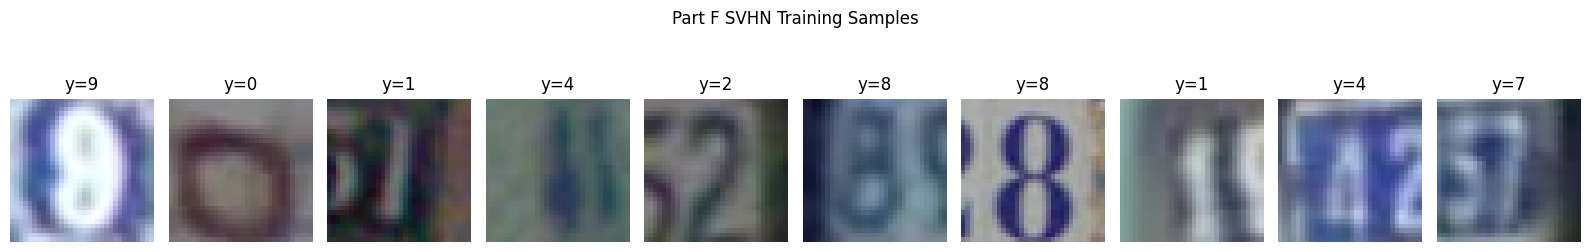

Saved: /content/q1_part_f_outputs/part_f_svhn_training_samples.png


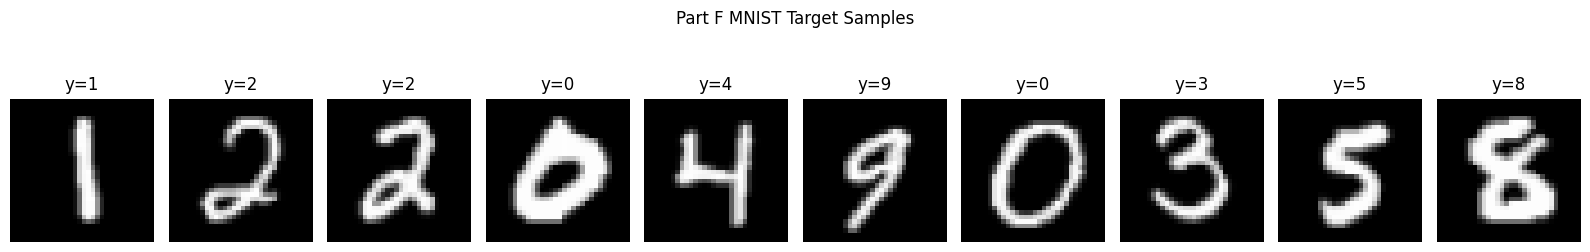

Saved: /content/q1_part_f_outputs/part_f_mnist_target_samples.png


In [ ]:
def unnormalize(img):
    img = img * 0.5 + 0.5
    return img.clamp(0, 1)


def show_batch(loader, title, n=10):
    images, labels = next(iter(loader))

    images = images[:n]
    labels = labels[:n]

    plt.figure(figsize=(16, 3))

    for i in range(n):
        img = unnormalize(images[i]).permute(1, 2, 0).cpu().numpy()
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f"y={labels[i].item()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()

    fig_path = os.path.join(OUTPUT_DIR, title.replace(" ", "_").lower() + ".png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)


show_batch(svhn_train_loader, "Part F SVHN Training Samples", n=10)
show_batch(mnist_test_loader, "Part F MNIST Target Samples", n=10)

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, use_bn=True):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(planes) if use_bn else nn.Identity()

        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(planes) if use_bn else nn.Identity()

        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes,
                    planes * self.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(planes * self.expansion) if use_bn else nn.Identity()
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)

        return out


class ResNet18FeatureExtractor(nn.Module):
    """
    Manual ResNet18 adapted for 32x32 images.
    Outputs 512-dimensional features.
    """

    def __init__(self, use_bn=True):
        super().__init__()

        self.in_planes = 64
        self.use_bn = use_bn

        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64) if use_bn else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)

        layers = []
        for s in strides:
            layers.append(
                BasicBlock(
                    in_planes=self.in_planes,
                    planes=planes,
                    stride=s,
                    use_bn=self.use_bn
                )
            )
            self.in_planes = planes * BasicBlock.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        features = torch.flatten(out, 1)

        return features


class CrossEntropyModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = ResNet18FeatureExtractor(use_bn=True)
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x, labels=None):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits

    def extract_features(self, x):
        return self.backbone(x)


# Quick test
test_model = CrossEntropyModel(num_classes=10).to(device)
dummy = torch.randn(2, 3, 32, 32).to(device)
dummy_logits = test_model(dummy)
dummy_features = test_model.extract_features(dummy)

print("Logits shape:", dummy_logits.shape)
print("Feature shape:", dummy_features.shape)

del test_model
torch.cuda.empty_cache()

Logits shape: torch.Size([2, 10])
Feature shape: torch.Size([2, 512])


In [ ]:
class ArcMarginProduct(nn.Module):
    """
    ArcFace-like angular margin head.

    During training:
        forward(features, labels) applies angular margin to the target class.

    During evaluation:
        forward(features, labels=None) returns scaled cosine logits.
    """

    def __init__(self, in_features=512, out_features=10, s=30.0, m=0.50, easy_margin=False):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.easy_margin = easy_margin

        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = np.cos(m)
        self.sin_m = np.sin(m)
        self.th = np.cos(np.pi - m)
        self.mm = np.sin(np.pi - m) * m

    def forward(self, features, labels=None):
        cosine = F.linear(
            F.normalize(features),
            F.normalize(self.weight)
        )

        if labels is None:
            return cosine * self.s

        sine = torch.sqrt(torch.clamp(1.0 - torch.pow(cosine, 2), min=1e-7))
        phi = cosine * self.cos_m - sine * self.sin_m

        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1.0)

        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output = output * self.s

        return output


class AngularMetricModel(nn.Module):
    def __init__(self, num_classes=10, s=30.0, m=0.50):
        super().__init__()
        self.backbone = ResNet18FeatureExtractor(use_bn=True)
        self.arc_head = ArcMarginProduct(
            in_features=512,
            out_features=num_classes,
            s=s,
            m=m
        )

    def forward(self, x, labels=None):
        features = self.backbone(x)
        logits = self.arc_head(features, labels)
        return logits

    def extract_features(self, x):
        return self.backbone(x)


# Quick test
test_metric_model = AngularMetricModel(num_classes=10).to(device)
dummy = torch.randn(2, 3, 32, 32).to(device)
dummy_labels = torch.tensor([0, 1]).to(device)

dummy_logits_train = test_metric_model(dummy, dummy_labels)
dummy_logits_eval = test_metric_model(dummy, labels=None)
dummy_features = test_metric_model.extract_features(dummy)

print("Metric train logits shape:", dummy_logits_train.shape)
print("Metric eval logits shape:", dummy_logits_eval.shape)
print("Metric feature shape:", dummy_features.shape)

del test_metric_model
torch.cuda.empty_cache()

Metric train logits shape: torch.Size([2, 10])
Metric eval logits shape: torch.Size([2, 10])
Metric feature shape: torch.Size([2, 512])


In [ ]:
def train_one_epoch_metric(model, loader, criterion, optimizer, device, model_type="ce"):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        if model_type == "angular":
            logits = model(images, labels)
        else:
            logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        with torch.no_grad():
            if model_type == "angular":
                eval_logits = model(images, labels=None)
                preds = eval_logits.argmax(dim=1)
            else:
                preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += batch_size

        progress_bar.set_postfix({
            "loss": running_loss / total,
            "acc": correct / total
        })

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate_metric(model, loader, criterion, device, model_type="ce"):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if model_type == "angular":
            loss_logits = model(images, labels)
            loss = criterion(loss_logits, labels)

            logits = model(images, labels=None)
        else:
            logits = model(images)
            loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    return running_loss / total, correct / total


print("Training/evaluation functions are ready.")

Training/evaluation functions are ready.


In [ ]:
def run_part_f_experiment(
    experiment_name,
    model,
    model_type="ce",
    epochs=12,
    lr=1e-3,
    weight_decay=5e-4
):
    print("=" * 80)
    print(f"Experiment: {experiment_name}")
    print(f"Model type: {model_type}")
    print("=" * 80)

    set_seed(SEED)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = []

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch_metric(
            model=model,
            loader=svhn_train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            model_type=model_type
        )

        svhn_loss, svhn_acc = evaluate_metric(
            model=model,
            loader=svhn_test_loader,
            criterion=criterion,
            device=device,
            model_type=model_type
        )

        mnist_loss, mnist_acc = evaluate_metric(
            model=model,
            loader=mnist_test_loader,
            criterion=criterion,
            device=device,
            model_type=model_type
        )

        scheduler.step()

        row = {
            "experiment": experiment_name,
            "model_type": model_type,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "svhn_test_loss": svhn_loss,
            "svhn_test_acc": svhn_acc,
            "mnist_test_loss": mnist_loss,
            "mnist_test_acc": mnist_acc,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": time.time() - epoch_start
        }

        history.append(row)

        print(
            f"Epoch [{epoch:02d}/{epochs}] | "
            f"Train Acc: {train_acc:.4f} | "
            f"SVHN Acc: {svhn_acc:.4f} | "
            f"MNIST Acc: {mnist_acc:.4f} | "
            f"Time: {row['epoch_time_sec']:.1f}s"
        )

    total_time = time.time() - start_time
    print(f"Total time for {experiment_name}: {total_time / 60:.2f} minutes")

    history_df = pd.DataFrame(history)

    history_path = os.path.join(OUTPUT_DIR, f"{experiment_name}_history.csv")
    history_df.to_csv(history_path, index=False)

    model_path = os.path.join(OUTPUT_DIR, f"{experiment_name}_model.pth")
    torch.save({
        "experiment_name": experiment_name,
        "model_type": model_type,
        "model_state_dict": model.state_dict(),
        "history": history,
        "config": {
            "train_dataset": "SVHN",
            "test_datasets": ["SVHN", "MNIST"],
            "epochs": epochs,
            "lr": lr,
            "weight_decay": weight_decay,
            "train_subset": SVHN_TRAIN_SUBSET_F if USE_SUBSET_F else "full"
        }
    }, model_path)

    print("Saved history:", history_path)
    print("Saved model:", model_path)

    return model, history_df

In [ ]:
torch.cuda.empty_cache()

ce_model = CrossEntropyModel(num_classes=10)

ce_model, ce_history_df = run_part_f_experiment(
    experiment_name="F_CrossEntropy_Model",
    model=ce_model,
    model_type="ce",
    epochs=EPOCHS_F,
    lr=LR_F,
    weight_decay=WEIGHT_DECAY_F
)

ce_history_df

Experiment: F_CrossEntropy_Model
Model type: ce


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [01/12] | Train Acc: 0.1066 | SVHN Acc: 0.1070 | MNIST Acc: 0.0990 | Time: 7.1s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [02/12] | Train Acc: 0.1482 | SVHN Acc: 0.1560 | MNIST Acc: 0.1330 | Time: 6.4s


...

Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [11/12] | Train Acc: 0.9880 | SVHN Acc: 0.8770 | MNIST Acc: 0.6120 | Time: 6.6s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [12/12] | Train Acc: 0.9934 | SVHN Acc: 0.8770 | MNIST Acc: 0.6080 | Time: 6.9s
Total time for F_CrossEntropy_Model: 1.33 minutes
Saved history: /content/q1_part_f_outputs/F_CrossEntropy_Model_history.csv
Saved model: /content/q1_part_f_outputs/F_CrossEntropy_Model_model.pth


,experiment,model_type,epoch,train_loss,train_acc,svhn_test_loss,svhn_test_acc,mnist_test_loss,mnist_test_acc,lr,epoch_time_sec
0,F_CrossEntropy_Model,ce,1,2.436671,0.1066,2.435798,0.107,2.406284,0.099,0.000983,7.111338
1,F_CrossEntropy_Model,ce,2,2.286727,0.1482,2.302186,0.156,2.276756,0.133,0.000933,6.436765
2,F_CrossEntropy_Model,ce,3,1.987216,0.2882,2.712430,0.209,2.725910,0.265,0.000854,6.481757
3,F_CrossEntropy_Model,ce,4,1.238815,0.5872,1.409614,0.581,2.223719,0.405,0.000750,6.532410
4,F_CrossEntropy_Model,ce,5,0.697648,0.7730,0.679611,0.761,1.481450,0.553,0.000629,6.479211
5,F_CrossEntropy_Model,ce,6,0.465293,0.8502,0.588006,0.814,1.019878,0.660,0.000500,6.698715
6,F_CrossEntropy_Model,ce,7,0.337262,0.8942,0.518553,0.833,1.426735,0.602,0.000371,6.446491
7,F_CrossEntropy_Model,ce,8,0.216348,0.9352,0.539875,0.827,1.810378,0.589,0.000250,6.714669
8,F_CrossEntropy_Model,ce,9,0.178184,0.9512,0.422706,0.869,1.250040,0.630,0.000146,6.509585
9,F_CrossEntropy_Model,ce,10,0.102741,0.9756,0.392785,0.871,1.368034,0.632,0.000067,6.794080


In [ ]:
torch.cuda.empty_cache()

angular_model = AngularMetricModel(num_classes=10, s=30.0, m=0.50)

angular_model, angular_history_df = run_part_f_experiment(
    experiment_name="F_AngularMetric_Model",
    model=angular_model,
    model_type="angular",
    epochs=EPOCHS_F,
    lr=LR_F,
    weight_decay=WEIGHT_DECAY_F
)

angular_history_df

Experiment: F_AngularMetric_Model
Model type: angular


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [01/12] | Train Acc: 0.1522 | SVHN Acc: 0.1150 | MNIST Acc: 0.1000 | Time: 8.6s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [02/12] | Train Acc: 0.1644 | SVHN Acc: 0.1220 | MNIST Acc: 0.1000 | Time: 8.6s


...

Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [11/12] | Train Acc: 0.8132 | SVHN Acc: 0.7410 | MNIST Acc: 0.5270 | Time: 8.8s


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [12/12] | Train Acc: 0.8316 | SVHN Acc: 0.7380 | MNIST Acc: 0.5050 | Time: 8.8s
Total time for F_AngularMetric_Model: 1.76 minutes
Saved history: /content/q1_part_f_outputs/F_AngularMetric_Model_history.csv
Saved model: /content/q1_part_f_outputs/F_AngularMetric_Model_model.pth


,experiment,model_type,epoch,train_loss,train_acc,svhn_test_loss,svhn_test_acc,mnist_test_loss,mnist_test_acc,lr,epoch_time_sec
0,F_AngularMetric_Model,angular,1,16.726956,0.1522,15.903284,0.115,16.672110,0.100,0.000983,8.638936
1,F_AngularMetric_Model,angular,2,14.722379,0.1644,13.727756,0.122,13.270942,0.100,0.000933,8.621875
2,F_AngularMetric_Model,angular,3,11.521918,0.1490,9.279490,0.124,12.608489,0.112,0.000854,8.605729
3,F_AngularMetric_Model,angular,4,8.392775,0.1584,9.362513,0.145,9.241900,0.086,0.000750,8.897896
4,F_AngularMetric_Model,angular,5,9.149754,0.2248,8.979566,0.267,9.244467,0.187,0.000629,8.952071
5,F_AngularMetric_Model,angular,6,8.600484,0.3702,8.422936,0.413,8.630894,0.414,0.000500,9.143174
6,F_AngularMetric_Model,angular,7,7.960910,0.5500,7.503629,0.577,7.676197,0.472,0.000371,8.709205
7,F_AngularMetric_Model,angular,8,7.446369,0.6674,7.199251,0.666,8.212709,0.457,0.000250,8.836524
8,F_AngularMetric_Model,angular,9,7.093507,0.7410,7.090909,0.680,8.039047,0.441,0.000146,8.696469
9,F_AngularMetric_Model,angular,10,6.819311,0.7788,7.120881,0.721,7.988882,0.497,0.000067,8.644256


In [ ]:

ce_final = ce_history_df.iloc[-1]
angular_final = angular_history_df.iloc[-1]

part_f_summary_df = pd.DataFrame([
    {
        "experiment": "CrossEntropy",
        "loss_type": "CrossEntropyLoss",
        "final_train_acc": ce_final["train_acc"],
        "final_svhn_test_acc": ce_final["svhn_test_acc"],
        "final_mnist_test_acc": ce_final["mnist_test_acc"],
        "final_svhn_test_loss": ce_final["svhn_test_loss"],
        "final_mnist_test_loss": ce_final["mnist_test_loss"],
        "domain_gap_svhn_minus_mnist": ce_final["svhn_test_acc"] - ce_final["mnist_test_acc"]
    },
    {
        "experiment": "AngularMetric",
        "loss_type": "Angular Margin Loss",
        "final_train_acc": angular_final["train_acc"],
        "final_svhn_test_acc": angular_final["svhn_test_acc"],
        "final_mnist_test_acc": angular_final["mnist_test_acc"],
        "final_svhn_test_loss": angular_final["svhn_test_loss"],
        "final_mnist_test_loss": angular_final["mnist_test_loss"],
        "domain_gap_svhn_minus_mnist": angular_final["svhn_test_acc"] - angular_final["mnist_test_acc"]
    }
])

summary_path = os.path.join(OUTPUT_DIR, "part_f_final_summary.csv")
part_f_summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
part_f_summary_df

Saved: /content/q1_part_f_outputs/part_f_final_summary.csv


,experiment,loss_type,final_train_acc,final_svhn_test_acc,final_mnist_test_acc,final_svhn_test_loss,final_mnist_test_loss,domain_gap_svhn_minus_mnist
0,CrossEntropy,CrossEntropyLoss,0.9934,0.877,0.608,0.400933,1.507726,0.269
1,AngularMetric,Angular Margin Loss,0.8316,0.738,0.505,7.055631,8.346262,0.233


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل عددی بخش و: یادگیری متریک</h3>

<p>
در این بخش مدل CrossEntropy با مدل Angular Metric مقایسه شده است. انتظار نظری این بود که یادگیری متریک با افزایش فاصله بین کلاس‌ها و کاهش فاصله درون‌کلاسی، فضای ویژگی پایدارتری ایجاد کند. اما نتایج نشان می‌دهد که در این تنظیمات، مدل CrossEntropy عملکرد بهتری داشته است.
</p>

<p>
مدل CrossEntropy به دقت 0.877 روی SVHN و 0.608 روی MNIST رسیده، در حالی که مدل Angular Metric به ترتیب دقت‌های 0.738 و 0.505 را کسب کرده است. بنابراین Angular Metric در این آزمایش باعث بهبود عملکرد طبقه‌بندی نشده است. کوچکتر بودن نسبی Domain Gap در مدل Angular نیز به تنهایی نشانه تعمیم بهتر نیست، زیرا دقت کلی آن روی هر دو دامنه پایین‌تر است.
</p>

</div>

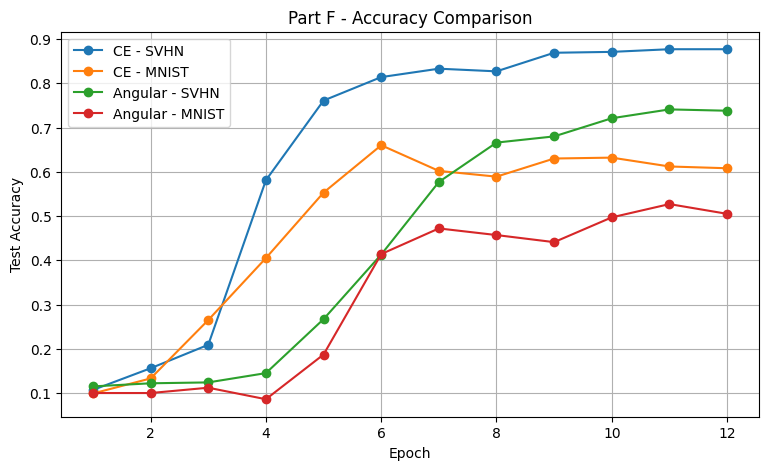

Saved: /content/q1_part_f_outputs/part_f_accuracy_comparison.png


In [ ]:

plt.figure(figsize=(9, 5))

plt.plot(
    ce_history_df["epoch"],
    ce_history_df["svhn_test_acc"],
    marker="o",
    label="CE - SVHN"
)

plt.plot(
    ce_history_df["epoch"],
    ce_history_df["mnist_test_acc"],
    marker="o",
    label="CE - MNIST"
)

plt.plot(
    angular_history_df["epoch"],
    angular_history_df["svhn_test_acc"],
    marker="o",
    label="Angular - SVHN"
)

plt.plot(
    angular_history_df["epoch"],
    angular_history_df["mnist_test_acc"],
    marker="o",
    label="Angular - MNIST"
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Part F - Accuracy Comparison")
plt.legend()
plt.grid(True)

acc_path = os.path.join(OUTPUT_DIR, "part_f_accuracy_comparison.png")
plt.savefig(acc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", acc_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمودار دقت بخش و</h3>

<p>
نمودار دقت نشان می‌دهد که مدل CrossEntropy از epochهای ابتدایی سریع‌تر همگرا شده و در پایان نیز روی هر دو دامنه SVHN و MNIST دقت بالاتری نسبت به مدل Angular Metric دارد. مدل Angular Metric روند رشد کندتری دارد و در نهایت به سطح عملکرد CrossEntropy نمی‌رسد.
</p>

<p>
این نتیجه نشان می‌دهد که یادگیری متریک به تنظیمات آموزشی حساس است. عواملی مانند مقدار margin، مقدار scale، اندازه batch، تعداد epoch و شدت domain shift می‌توانند روی موفقیت این روش اثر بگذارند. بنابراین استفاده از loss متریک به تنهایی تضمین‌کننده بهبود تعمیم بین‌دامنه‌ای نیست.
</p>

</div>

In [ ]:
@torch.no_grad()
def extract_features_for_umap(model, loader, device, max_samples=1000):
    model.eval()

    all_features = []
    all_labels = []

    total = 0

    for images, labels in loader:
        images = images.to(device)

        features = model.extract_features(images)

        all_features.append(features.detach().cpu())
        all_labels.append(labels.detach().cpu())

        total += labels.size(0)

        if total >= max_samples:
            break

    features = torch.cat(all_features, dim=0)[:max_samples]
    labels = torch.cat(all_labels, dim=0)[:max_samples]

    features_np = features.numpy()
    labels_np = labels.numpy()

    return features_np, labels_np


print("Extracting CE features...")
ce_svhn_features, ce_svhn_labels = extract_features_for_umap(
    ce_model,
    svhn_test_loader,
    device,
    max_samples=UMAP_MAX_SAMPLES
)

ce_mnist_features, ce_mnist_labels = extract_features_for_umap(
    ce_model,
    mnist_test_loader,
    device,
    max_samples=UMAP_MAX_SAMPLES
)

print("Extracting Angular features...")
angular_svhn_features, angular_svhn_labels = extract_features_for_umap(
    angular_model,
    svhn_test_loader,
    device,
    max_samples=UMAP_MAX_SAMPLES
)

angular_mnist_features, angular_mnist_labels = extract_features_for_umap(
    angular_model,
    mnist_test_loader,
    device,
    max_samples=UMAP_MAX_SAMPLES
)

print("CE SVHN features:", ce_svhn_features.shape)
print("CE MNIST features:", ce_mnist_features.shape)
print("Angular SVHN features:", angular_svhn_features.shape)
print("Angular MNIST features:", angular_mnist_features.shape)

Extracting CE features...
Extracting Angular features...
CE SVHN features: (1000, 512)
CE MNIST features: (1000, 512)
Angular SVHN features: (1000, 512)
Angular MNIST features: (1000, 512)


In [ ]:
def compute_umap(features, seed=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=seed
    )

    features_2d = reducer.fit_transform(features)
    return features_2d


print("Computing UMAP projections...")

ce_svhn_umap = compute_umap(ce_svhn_features, seed=SEED)
ce_mnist_umap = compute_umap(ce_mnist_features, seed=SEED)

angular_svhn_umap = compute_umap(angular_svhn_features, seed=SEED)
angular_mnist_umap = compute_umap(angular_mnist_features, seed=SEED)

print("UMAP done.")

Computing UMAP projections...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.


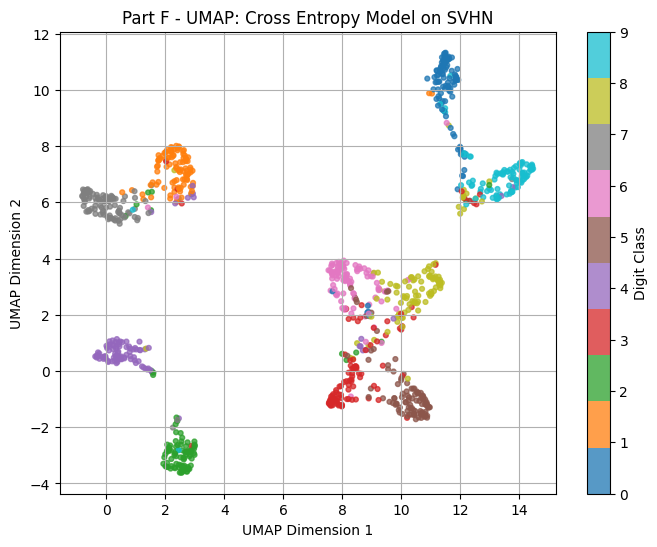

Saved: /content/q1_part_f_outputs/part_f_umap_ce_svhn.png


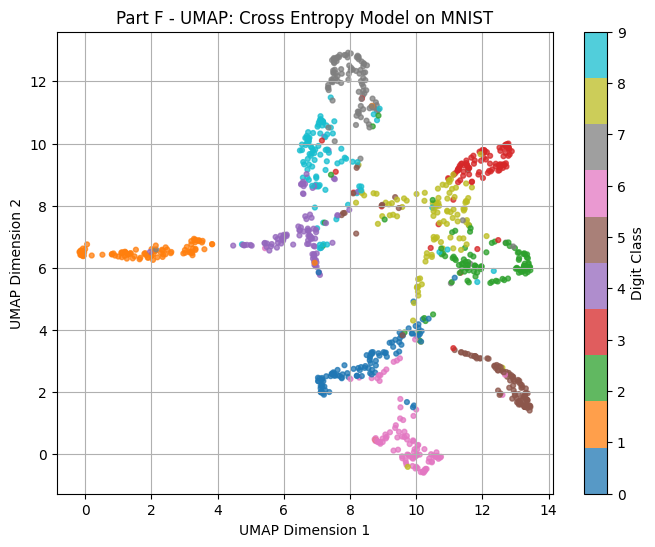

Saved: /content/q1_part_f_outputs/part_f_umap_ce_mnist.png


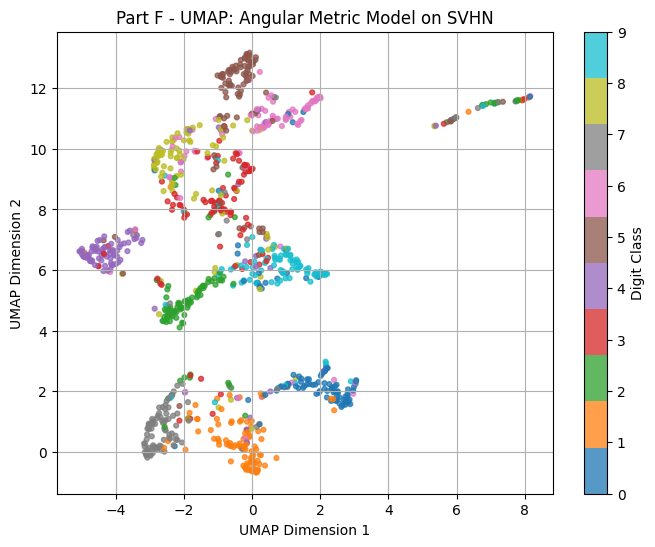

Saved: /content/q1_part_f_outputs/part_f_umap_angular_svhn.png


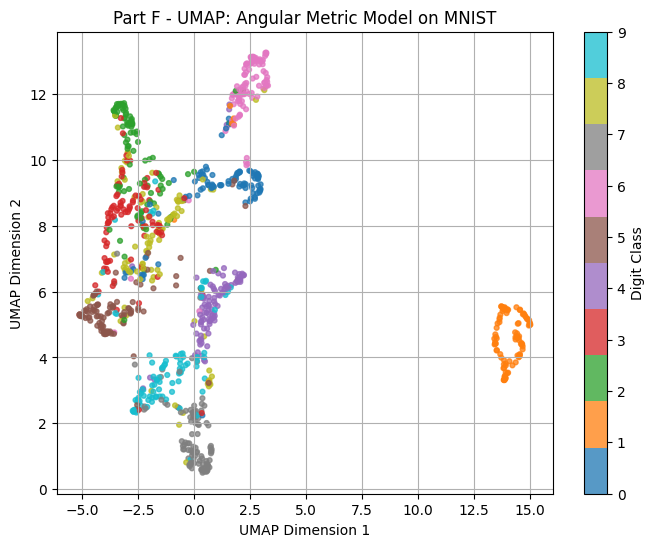

Saved: /content/q1_part_f_outputs/part_f_umap_angular_mnist.png


In [ ]:
def plot_umap(features_2d, labels, title, filename):
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        features_2d[:, 0],
        features_2d[:, 1],
        c=labels,
        cmap="tab10",
        s=12,
        alpha=0.75
    )

    cbar = plt.colorbar(scatter, ticks=list(range(10)))
    cbar.set_label("Digit Class")

    plt.title(title)
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.grid(True)

    fig_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fig_path)


plot_umap(
    ce_svhn_umap,
    ce_svhn_labels,
    "Part F - UMAP: Cross Entropy Model on SVHN",
    "part_f_umap_ce_svhn.png"
)

plot_umap(
    ce_mnist_umap,
    ce_mnist_labels,
    "Part F - UMAP: Cross Entropy Model on MNIST",
    "part_f_umap_ce_mnist.png"
)

plot_umap(
    angular_svhn_umap,
    angular_svhn_labels,
    "Part F - UMAP: Angular Metric Model on SVHN",
    "part_f_umap_angular_svhn.png"
)

plot_umap(
    angular_mnist_umap,
    angular_mnist_labels,
    "Part F - UMAP: Angular Metric Model on MNIST",
    "part_f_umap_angular_mnist.png"
)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل UMAP فضای ویژگی</h3>

<p>
نمودارهای UMAP برای بررسی هندسه فضای ویژگی مدل‌ها استفاده شده‌اند. در این نمودارها، هر نقطه یک نمونه تصویر است و رنگ نقطه نشان‌دهنده کلاس واقعی رقم است. هرچه نقاط مربوط به یک کلاس فشرده‌تر و کلاس‌های مختلف از هم جدا‌تر باشند، فضای ویژگی مدل منظم‌تر و قابل‌اعتمادتر است.
</p>

<p>
نمودارها نشان می‌دهند که مدل CrossEntropy به‌ویژه روی SVHN خوشه‌های واضح‌تر و جداپذیرتری ساخته است. روی MNIST نیز با وجود domain shift، ساختار برخی کلاس‌ها همچنان قابل مشاهده است. در مقابل، مدل Angular Metric تداخل بیشتری بین کلاس‌ها دارد و خوشه‌ها فشردگی و جدایی کمتری نشان می‌دهند. بنابراین برخلاف انتظار نظری، مدل Angular در این آزمایش فضای ویژگی پایدارتری ایجاد نکرده است.
</p>

</div>

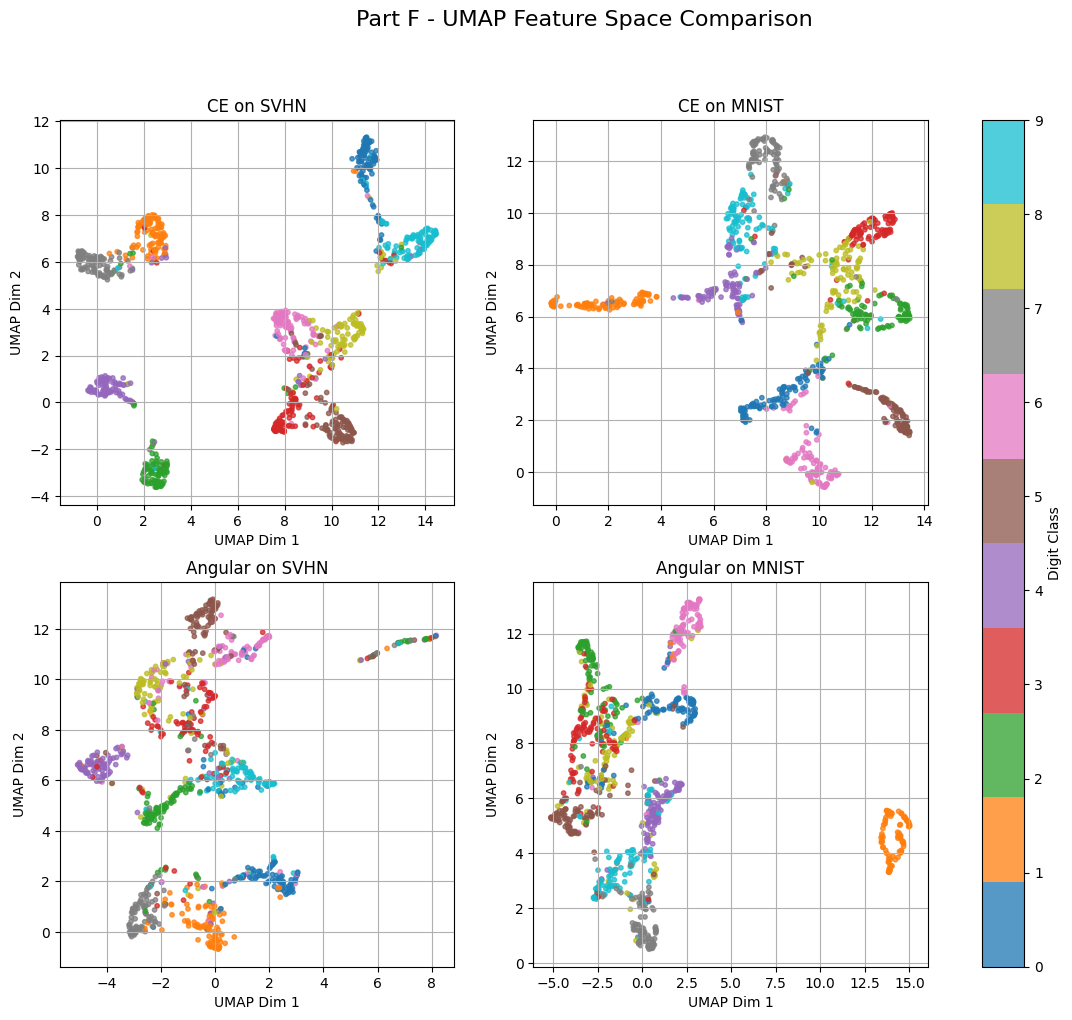

Saved: /content/q1_part_f_outputs/part_f_umap_combined_comparison.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

plots = [
    (ce_svhn_umap, ce_svhn_labels, "CE on SVHN"),
    (ce_mnist_umap, ce_mnist_labels, "CE on MNIST"),
    (angular_svhn_umap, angular_svhn_labels, "Angular on SVHN"),
    (angular_mnist_umap, angular_mnist_labels, "Angular on MNIST")
]

for ax, (features_2d, labels, title) in zip(axes.flatten(), plots):
    sc = ax.scatter(
        features_2d[:, 0],
        features_2d[:, 1],
        c=labels,
        cmap="tab10",
        s=10,
        alpha=0.75
    )

    ax.set_title(title)
    ax.set_xlabel("UMAP Dim 1")
    ax.set_ylabel("UMAP Dim 2")
    ax.grid(True)

fig.colorbar(sc, ax=axes.ravel().tolist(), ticks=list(range(10)), label="Digit Class")
fig.suptitle("Part F - UMAP Feature Space Comparison", fontsize=16)

combined_path = os.path.join(OUTPUT_DIR, "part_f_umap_combined_comparison.png")
plt.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", combined_path)

In [ ]:
def safe_silhouette(features, labels, name):
    try:
        score = silhouette_score(features, labels)
        print(f"{name} Silhouette Score: {score:.4f}")
        return score
    except Exception as e:
        print(f"Could not compute silhouette for {name}: {e}")
        return None


ce_svhn_sil = safe_silhouette(ce_svhn_umap, ce_svhn_labels, "CE SVHN")
ce_mnist_sil = safe_silhouette(ce_mnist_umap, ce_mnist_labels, "CE MNIST")
angular_svhn_sil = safe_silhouette(angular_svhn_umap, angular_svhn_labels, "Angular SVHN")
angular_mnist_sil = safe_silhouette(angular_mnist_umap, angular_mnist_labels, "Angular MNIST")

part_f_silhouette_df = pd.DataFrame([
    {
        "model": "CrossEntropy",
        "dataset": "SVHN",
        "silhouette_score": ce_svhn_sil
    },
    {
        "model": "CrossEntropy",
        "dataset": "MNIST",
        "silhouette_score": ce_mnist_sil
    },
    {
        "model": "AngularMetric",
        "dataset": "SVHN",
        "silhouette_score": angular_svhn_sil
    },
    {
        "model": "AngularMetric",
        "dataset": "MNIST",
        "silhouette_score": angular_mnist_sil
    }
])

sil_path = os.path.join(OUTPUT_DIR, "part_f_silhouette_scores.csv")
part_f_silhouette_df.to_csv(sil_path, index=False)

print("Saved:", sil_path)
part_f_silhouette_df

CE SVHN Silhouette Score: 0.4040
CE MNIST Silhouette Score: 0.3693
Angular SVHN Silhouette Score: 0.1173
Angular MNIST Silhouette Score: 0.2664
Saved: /content/q1_part_f_outputs/part_f_silhouette_scores.csv


,model,dataset,silhouette_score
0,CrossEntropy,SVHN,0.404002
1,CrossEntropy,MNIST,0.369291
2,AngularMetric,SVHN,0.117325
3,AngularMetric,MNIST,0.266355


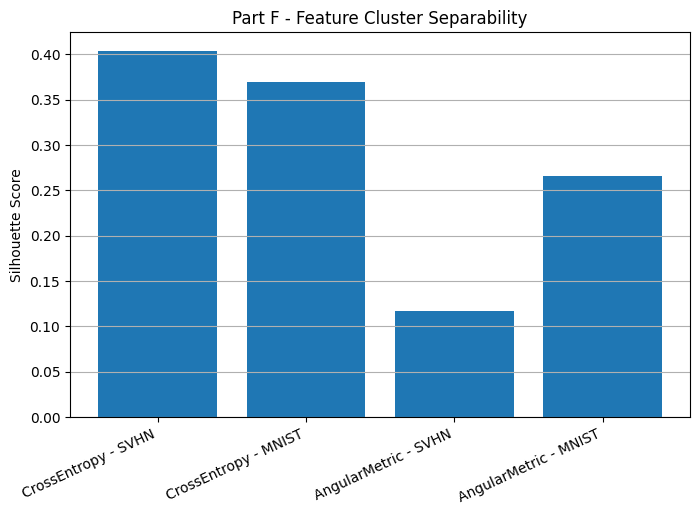

Saved: /content/q1_part_f_outputs/part_f_silhouette_scores.png


In [ ]:
plt.figure(figsize=(8, 5))

labels_for_plot = (
    part_f_silhouette_df["model"] + " - " + part_f_silhouette_df["dataset"]
)

plt.bar(
    labels_for_plot,
    part_f_silhouette_df["silhouette_score"]
)

plt.ylabel("Silhouette Score")
plt.title("Part F - Feature Cluster Separability")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")

sil_fig_path = os.path.join(OUTPUT_DIR, "part_f_silhouette_scores.png")
plt.savefig(sil_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", sil_fig_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل Silhouette Score</h3>

<p>
Silhouette Score نتیجه کیفی نمودارهای UMAP را به صورت عددی تأیید می‌کند. مقدار این معیار برای مدل CrossEntropy روی SVHN برابر 0.404 و روی MNIST برابر 0.369 است. در مقابل، مدل Angular Metric روی SVHN مقدار 0.117 و روی MNIST مقدار 0.266 را به دست آورده است.
</p>

<p>
بنابراین مدل CrossEntropy در هر دو دامنه فضای ویژگی جداپذیرتر و منظم‌تری ایجاد کرده است. این نتیجه نشان می‌دهد که در این آزمایش، CrossEntropy نه‌تنها از نظر دقت، بلکه از نظر کیفیت خوشه‌بندی ویژگی‌ها نیز بهتر از Angular Metric عمل کرده است.
</p>

</div>

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>جمع‌بندی نهایی پرسش ۱</h3>

<p>
نتایج کلی این نوت‌بوک نشان می‌دهد که مسئله اصلی در انتقال بین SVHN و MNIST ناشی از covariate shift است. هر دو مجموعه‌داده شامل ارقام ۰ تا ۹ هستند، اما ظاهر تصاویر، رنگ، بافت، پس‌زمینه و سبک تصویربرداری آن‌ها متفاوت است. به همین دلیل، مدلی که روی یک دامنه آموزش می‌بیند الزاماً روی دامنه دیگر عملکرد پایداری ندارد.
</p>

<p>
در بخش‌های مختلف مشاهده شد که روش‌هایی مانند Label Smoothing، Transfer Learning و Domain Adaptation می‌توانند تا حدی به کاهش اثر تغییر دامنه کمک کنند. Label Smoothing با کاهش overconfidence عملکرد بهتری روی MNIST ایجاد کرد. Full Fine-tuning نسبت به Linear Probing بهتر بود، زیرا کل feature extractor امکان سازگاری با دامنه ارقام را داشت. همچنین استفاده از ۵۰۰ نمونه برچسب‌دار SVHN باعث بهبود قابل توجه عملکرد روی دامنه هدف شد.
</p>

<p>
از طرف دیگر، نتایج Data Augmentation و Metric Learning نشان داد که روش‌های نظری همیشه در عمل باعث بهبود مستقیم نمی‌شوند. موفقیت این روش‌ها به نوع transformation، تنظیمات آموزشی، hyperparameterها و شدت اختلاف دامنه وابسته است. بنابراین برای ساخت مدل قابل اعتماد، فقط دقت روی داده منبع کافی نیست و باید تعمیم‌پذیری، اعتماد مدل، کیفیت فضای ویژگی و عملکرد روی دامنه‌های جدید نیز همزمان بررسی شوند.
</p>

</div>

# Conclusion

This experiment demonstrates that high performance on the training distribution does not necessarily guarantee reliable performance on unseen domains.

Key observations:

- Domain shift can significantly affect model performance.
- Models may learn domain-specific patterns instead of general representations.
- Representation analysis provides additional insights into model behavior.

Improving generalization is an essential component of trustworthy machine learning systems.